In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sankalp Roy\Documents\BACapstoneProject\workshop_coding_files\NSW_21_24_Price_Demand.csv")

# Check raw date format
print(df['SETTLEMENTDATE'].head())

0    2021-07-01 00:05:00
1    2021-07-01 00:10:00
2    2021-07-01 00:15:00
3    2021-07-01 00:20:00
4    2021-07-01 00:25:00
Name: SETTLEMENTDATE, dtype: str


In [92]:
df_copy1 = df.copy()

In [93]:
df_copy1['SETTLEMENTDATE'] = pd.to_datetime(
    df_copy1['SETTLEMENTDATE'].astype(str).str.strip(),
    format='%Y-%m-%d %H:%M:%S',
    errors='raise'
)

df_copy1 = df_copy1.sort_values('SETTLEMENTDATE').reset_index(drop=True)

expected_start = pd.Timestamp("2021-07-01 00:05:00")
expected_end = pd.Timestamp("2024-07-01 00:00:00")

expected_timestamps = pd.date_range(
    start=expected_start,
    end=expected_end,
    freq="5min"
)

actual_timestamps = pd.DatetimeIndex(df_copy1['SETTLEMENTDATE'])

missing_timestamps = expected_timestamps.difference(actual_timestamps)
duplicate_timestamps = df_copy1[df_copy1['SETTLEMENTDATE'].duplicated(keep=False)]
outside_range = df_copy1[
    (df_copy1['SETTLEMENTDATE'] < expected_start) |
    (df_copy1['SETTLEMENTDATE'] > expected_end)
]

print("Actual start:", df_copy1['SETTLEMENTDATE'].min())
print("Actual end:", df_copy1['SETTLEMENTDATE'].max())
print("Expected rows:", len(expected_timestamps))
print("Actual rows:", len(df_copy1))
print("Unique timestamps:", df_copy1['SETTLEMENTDATE'].nunique())
print("Missing timestamps:", len(missing_timestamps))
print("Duplicate rows:", len(duplicate_timestamps))
print("Rows outside expected range:", len(outside_range))

missing_timestamps[:20]

Actual start: 2021-07-01 00:05:00
Actual end: 2024-07-01 00:00:00
Expected rows: 315648
Actual rows: 315646
Unique timestamps: 315646
Missing timestamps: 2
Duplicate rows: 0
Rows outside expected range: 0


DatetimeIndex(['2023-12-05 13:45:00', '2023-12-05 13:50:00'], dtype='datetime64[us]', freq='5min')

In [95]:
# creating rows for the missing timestamps

missing_df = pd.DataFrame({
    'SETTLEMENTDATE': missing_timestamps
})

# merge and new

df_complete = pd.merge(
    pd.DataFrame({'SETTLEMENTDATE': expected_timestamps}),
    df_copy1,
    on='SETTLEMENTDATE',
    how='left'
)

The dataset covers 1 July 2021 to 1 July 2024 at 5-minute intervals. There are 315,646 records, with no duplicated timestamps and no rows outside the expected range. Two timestamps are missing: 2023-12-05 13:45 and 2023-12-05 13:50. These were left unchanged because no original data was available for those intervals.

In [98]:
df_clean = df_copy1.dropna(
    subset=['solar_dispatch', 'wind_dispatch', 'hydro_dispatch']
).copy()

df_clean.isna().sum()

SETTLEMENTDATE    0
NSW1_Price        0
NSW1_Demand       0
solar_dispatch    0
wind_dispatch     0
hydro_dispatch    0
dtype: int64

In [102]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
negative_counts = (df_clean[dispatch_cols] < 0).sum()

negative_counts

solar_dispatch      18
wind_dispatch       50
hydro_dispatch    1410
dtype: int64

In [103]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
hourly = (
    df_clean.groupby(df_clean['SETTLEMENTDATE'].dt.hour)
    [['solar_dispatch','wind_dispatch','hydro_dispatch']]
    .mean()
)

hourly

,solar_dispatch,wind_dispatch,hydro_dispatch
SETTLEMENTDATE,,,
0,0.073831,788.470630,320.805973
1,0.058519,778.487787,276.775685
2,0.055180,766.398998,244.910339
3,0.059215,755.239337,239.985079
4,0.069145,745.605469,254.547063
5,27.118263,731.305073,286.468619
6,305.057285,703.299287,338.890400
7,828.819172,651.701855,391.449849
8,1336.351746,593.427857,285.792176


In [104]:
# clipping negative dispatch data to zero

dispatch_cols = [
    'solar_dispatch',
    'wind_dispatch',
    'hydro_dispatch'
]

df_clean[dispatch_cols] = (
    df_clean[dispatch_cols]
    .clip(lower=0)
)

A small number of negative renewable dispatch values (<0.5% of observations) were observed. These were minor in magnitude and likely reflect telemetry, metering or operational adjustments. Values were truncated to zero because negative renewable generation is not meaningful for the aggregated renewable dispatch variables used in this study.

In [106]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Create date-only column
df_clean['Date'] = df_clean['SETTLEMENTDATE'].dt.date

# Count rows per date
rows_per_day = df_clean.groupby('Date').size()

# Dates with exactly 288 rows
complete_days = rows_per_day[rows_per_day == 288].index

# Keep only complete days
df_full_days = df_clean[df_clean['Date'].isin(complete_days)].copy()

print("Original rows:", len(df_clean))
print("Rows after keeping complete days:", len(df_full_days))
print("Number of complete days:", df_full_days['Date'].nunique())
print("Number of incomplete days removed:", (rows_per_day != 288).sum())

Original rows: 315645
Rows after keeping complete days: 315072
Number of complete days: 1094
Number of incomplete days removed: 2


In [107]:
incomplete_days = rows_per_day[rows_per_day != 288]

incomplete_days

Date
2021-07-01    287
2023-12-05    286
dtype: int64

To ensure consistent daily analysis, only complete days with 288 five-minute intervals were retained. This removed two incomplete days, representing approximately 0.18% of the dataset, so the impact on the overall analysis is minimal.

In [108]:
# creating new features from the datetime column

df_full_days['Hour'] = df_full_days['SETTLEMENTDATE'].dt.hour
df_full_days['DayOfWeek'] = df_full_days['SETTLEMENTDATE'].dt.dayofweek
df_full_days['MonthNo'] = df_full_days['SETTLEMENTDATE'].dt.month
df_full_days['MonthName'] = df_full_days['SETTLEMENTDATE'].dt.month_name()
df_full_days['Year'] = df_full_days['SETTLEMENTDATE'].dt.year

In [109]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
df_full_days = df_full_days.reset_index(drop=True)

In [110]:
df_full_days.info()

<class 'pandas.DataFrame'>
RangeIndex: 315072 entries, 0 to 315071
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   SETTLEMENTDATE  315072 non-null  datetime64[us]
 1   NSW1_Price      315072 non-null  float64       
 2   NSW1_Demand     315072 non-null  float64       
 3   solar_dispatch  315072 non-null  float64       
 4   wind_dispatch   315072 non-null  float64       
 5   hydro_dispatch  315072 non-null  float64       
 6   Date            315072 non-null  object        
 7   Hour            315072 non-null  int32         
 8   DayOfWeek       315072 non-null  int32         
 9   MonthNo         315072 non-null  int32         
 10  MonthName       315072 non-null  str           
 11  Year            315072 non-null  int32         
dtypes: datetime64[us](1), float64(5), int32(4), object(1), str(1)
memory usage: 25.9+ MB


In [111]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# creating seasonality columns
season_map = {
    12: 'Summer', 1: 'Summer', 2: 'Summer',
    3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
    6: 'Winter', 7: 'Winter', 8: 'Winter',
    9: 'Spring', 10: 'Spring', 11: 'Spring'
}

df_full_days['Season'] = df_full_days['MonthNo'].map(season_map)

In [112]:
df_full_days[['MonthName', 'Season']].drop_duplicates().sort_values('Season')

,MonthName,Season
69696,March,Autumn
78624,April,Autumn
87264,May,Autumn
17568,September,Spring
26208,October,Spring
35136,November,Spring
43776,December,Summer
52704,January,Summer
61632,February,Summer
0,July,Winter


In [114]:
df_full_days[['DayOfWeek', 'DayType']].drop_duplicates().sort_values('DayType')

,DayOfWeek,DayType
0,4,Weekday
864,0,Weekday
1152,1,Weekday
1440,2,Weekday
1728,3,Weekday
288,5,Weekend
576,6,Weekend


In [115]:

# 2. Calculate average NSW demand for each hour
hourly_demand_profile = (
    df_full_days
    .groupby('Hour')['NSW1_Demand']
    .mean()
    .reset_index()
    .rename(columns={'NSW1_Demand': 'Avg_Demand_MW'})
)

# 3. Create demand-based thresholds
low_threshold = hourly_demand_profile['Avg_Demand_MW'].quantile(0.25)
high_threshold = hourly_demand_profile['Avg_Demand_MW'].quantile(0.75)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

# 4. Classify each hour using demand quartiles
def classify_trading_period(avg_demand):
    if avg_demand >= high_threshold:
        return 'Peak'
    elif avg_demand <= low_threshold:
        return 'Off-Peak'
    else:
        return 'Shoulder'

hourly_demand_profile['TradingPeriod'] = (
    hourly_demand_profile['Avg_Demand_MW']
    .apply(classify_trading_period)
)

# 5. Check which hours were classified into each period
hourly_demand_profile.sort_values('Hour')

Low threshold: 6829.569504113346
High threshold: 8062.036799207799


,Hour,Avg_Demand_MW,TradingPeriod
0,0,7347.089374,Shoulder
1,1,6929.452888,Shoulder
2,2,6562.893285,Off-Peak
3,3,6409.085353,Off-Peak
4,4,6521.554379,Off-Peak
5,5,6945.033544,Shoulder
6,6,7524.101038,Shoulder
7,7,7817.202729,Shoulder
8,8,7625.369977,Shoulder
9,9,7211.479020,Shoulder


In [116]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
df_full_days = df_full_days.merge(
    hourly_demand_profile[['Hour', 'TradingPeriod']],
    on='Hour',
    how='left'
)

In [117]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Count observations by period
df_full_days['TradingPeriod'].value_counts()

# Check hour classification
hourly_demand_profile.sort_values('Hour')

,Hour,Avg_Demand_MW,TradingPeriod
0,0,7347.089374,Shoulder
1,1,6929.452888,Shoulder
2,2,6562.893285,Off-Peak
3,3,6409.085353,Off-Peak
4,4,6521.554379,Off-Peak
5,5,6945.033544,Shoulder
6,6,7524.101038,Shoulder
7,7,7817.202729,Shoulder
8,8,7625.369977,Shoulder
9,9,7211.479020,Shoulder


In [118]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, shapiro, probplot

demand = df_full_days['NSW1_Demand'].dropna()

# demand summary stats
demand_stats = {
    'Mean': demand.mean(),
    'Median': demand.median(),
    'Standard Deviation': demand.std(),
    'Min': demand.min(),
    'Max': demand.max(),
    'Range': demand.max() - demand.min(),
    'IQR': demand.quantile(0.75) - demand.quantile(0.25),
    'Skewness': skew(demand),
    'Kurtosis': kurtosis(demand, fisher=False)
}

demand_stats

{'Mean': np.float64(7539.790020661943),
 'Median': np.float64(7397.6),
 'Standard Deviation': np.float64(1319.6104503403185),
 'Min': np.float64(3664.34),
 'Max': np.float64(13763.96),
 'Range': np.float64(10099.619999999999),
 'IQR': np.float64(1694.8850000000011),
 'Skewness': np.float64(0.6010117440251581),
 'Kurtosis': np.float64(3.468272126356286)}

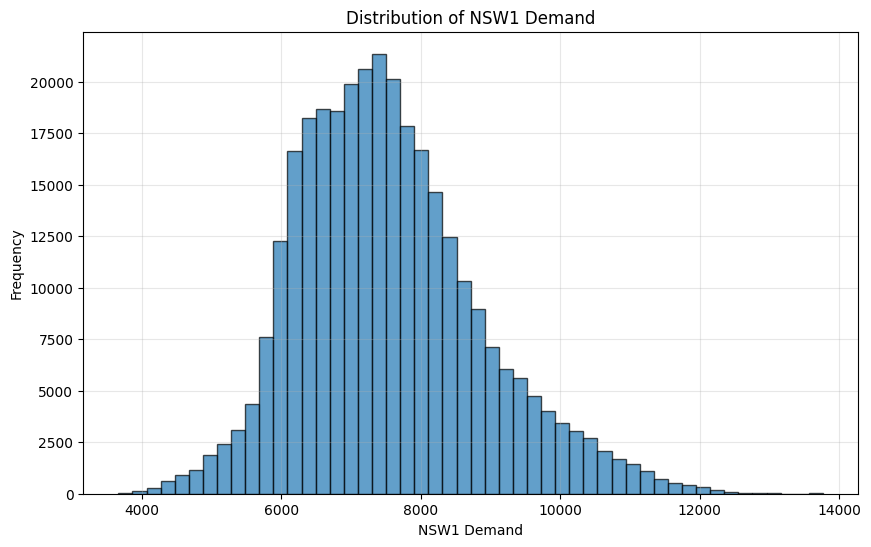

In [119]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# plotting histogram to check distribution of demand

plt.figure(figsize=(10, 6))
plt.hist(demand, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of NSW1 Demand')
plt.xlabel('NSW1 Demand')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

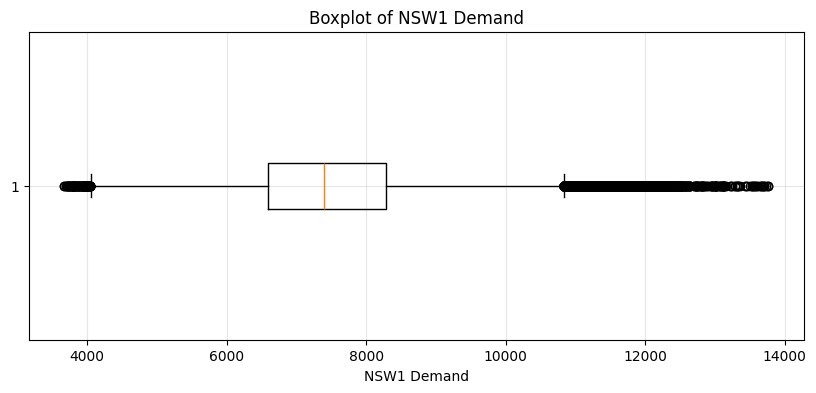

In [120]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# plotting boxplot to get a sense of outliers

plt.figure(figsize=(10, 4))
plt.boxplot(demand, vert=False)
plt.title('Boxplot of NSW1 Demand')
plt.xlabel('NSW1 Demand')
plt.grid(True, alpha=0.3)
plt.show()

In [121]:
# normality test

demand_sample = demand.sample(5000, random_state=42)

shapiro_stat, shapiro_p = shapiro(demand_sample)

print("Shapiro-Wilk statistic:", shapiro_stat)
print("p-value:", shapiro_p)

Shapiro-Wilk statistic: 0.977913354146109
p-value: 3.441096423315212e-27


### NSW Demand Distribution Analysis

The NSW demand data exhibits a realistic and well-behaved distribution, with an average demand of approximately **7,540 MW** and a median of **7,398 MW**. The mean being slightly higher than the median indicates the presence of occasional high-demand periods that pull the average upward.

The distribution shows **moderate variability** (standard deviation = **1,320 MW**) and demand ranges from approximately **3,664 MW** to **13,764 MW**, reflecting substantial differences between low-demand and peak-demand periods. The middle 50% of observations fall within an interquartile range (IQR) of **1,695 MW**, suggesting that most demand observations occur within a relatively stable operating band.

The histogram indicates a **unimodal and moderately right-skewed distribution** (skewness = **0.60**), meaning that extreme high-demand events occur less frequently but are still present in the dataset. The kurtosis value (**3.47**) suggests slightly heavier tails than a normal distribution, implying that extreme demand events occur somewhat more frequently than would be expected under perfect normality.

Although the Shapiro-Wilk test rejects normality (p < 0.001), this result is expected given the large sample size of over **315,000 observations** and does not indicate a data quality issue. Visual inspection of the histogram confirms that the demand profile is realistic and consistent with expected electricity consumption behaviour.

For the purposes of this analysis, the identified outliers are retained, as they likely represent genuine peak-demand and low-demand market conditions rather than erroneous observations. These periods are particularly important for Task 2, as wholesale electricity prices are often most sensitive to demand changes during periods of system stress and elevated demand.

Analysis of Price variable

In [122]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
price = df_full_days['NSW1_Price'].dropna()

# summary stats baby
price_stats = {
    'Mean': price.mean(),
    'Median': price.median(),
    'Standard Deviation': price.std(),
    'Min': price.min(),
    'Max': price.max(),
    'Range': price.max() - price.min(),
    'IQR': price.quantile(0.75) - price.quantile(0.25),
    'Skewness': skew(price),
    'Kurtosis': kurtosis(price, fisher=False)
}

price_stats

{'Mean': np.float64(126.31299670903793),
 'Median': np.float64(88.121285),
 'Standard Deviation': np.float64(382.8227617953295),
 'Min': np.float64(-999.99906),
 'Max': np.float64(16600.0),
 'Range': np.float64(17599.99906),
 'IQR': np.float64(81.5005075),
 'Skewness': np.float64(33.78077042455852),
 'Kurtosis': np.float64(1278.9728899176214)}

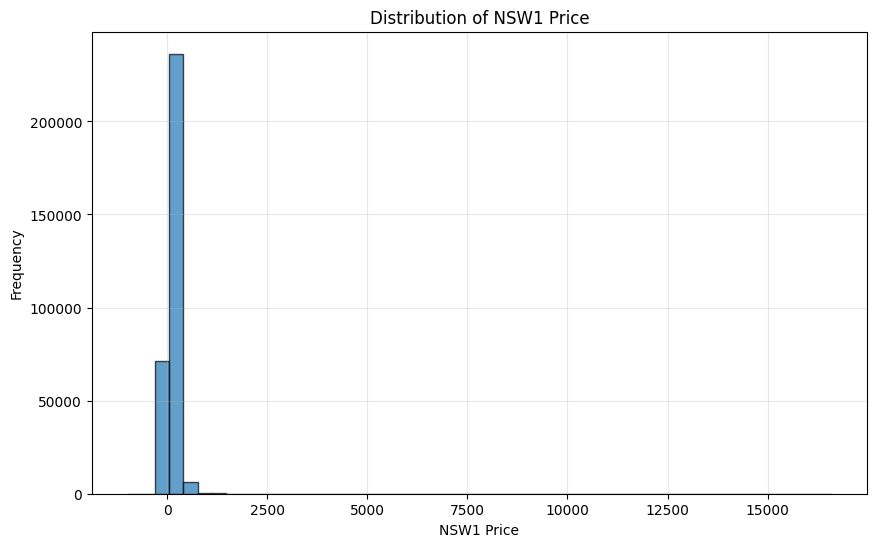

In [123]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# to check value distribution

plt.figure(figsize=(10, 6))
plt.hist(price, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of NSW1 Price')
plt.xlabel('NSW1 Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [125]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Calculate 1st and 99th percentile thresholds

p01 = df_full_days['NSW1_Price'].quantile(0.01)
p99 = df_full_days['NSW1_Price'].quantile(0.99)

print(f"1st Percentile : {p01:.2f}")
print(f"99th Percentile: {p99:.2f}")

1st Percentile : -47.84
99th Percentile: 523.40


In [126]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
price_extremes = df_full_days[
    (df_full_days['NSW1_Price'] < p01) |
    (df_full_days['NSW1_Price'] > p99)
]

print(f"Extreme observations: {len(price_extremes):,}")
print(
    f"Percentage excluded: "
    f"{len(price_extremes)/len(df_full_days)*100:.2f}%"
)

Extreme observations: 6,302
Percentage excluded: 2.00%


In [127]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
price_filtered = df_full_days[
    (df_full_days['NSW1_Price'] >= p01) &
    (df_full_days['NSW1_Price'] <= p99)
].copy()

In [128]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# understanding the influence of extreme outliers

comparison = pd.DataFrame({
    'Original': df_full_days['NSW1_Price'].describe(),
    'Filtered': price_filtered['NSW1_Price'].describe()
})

comparison

,Original,Filtered
count,315072.000000,308770.000000
mean,126.312997,112.635257
std,382.822762,92.142202
min,-999.999060,-47.836790
25%,58.000000,58.000150
50%,88.121285,88.121285
75%,139.500507,137.499255
max,16600.000000,523.384950


In [129]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# summary stats

# summary stats baby
price_filtered_stats = {
    'Mean': price_filtered['NSW1_Price'].mean(),
    'Median': price_filtered['NSW1_Price'].median(),
    'Standard Deviation': price_filtered['NSW1_Price'].std(),
    'Min': price_filtered['NSW1_Price'].min(),
    'Max': price_filtered['NSW1_Price'].max(),
    'Range': price_filtered['NSW1_Price'].max() - price_filtered['NSW1_Price'].min(),
    'IQR': price_filtered['NSW1_Price'].quantile(0.75) - price_filtered['NSW1_Price'].quantile(0.25),
    'Skewness': skew(price_filtered['NSW1_Price']),
    'Kurtosis': kurtosis(price_filtered['NSW1_Price'], fisher=False)
}

price_filtered_stats

{'Mean': np.float64(112.6352572823137),
 'Median': np.float64(88.121285),
 'Standard Deviation': np.float64(92.14220180649926),
 'Min': np.float64(-47.83679),
 'Max': np.float64(523.38495),
 'Range': np.float64(571.22174),
 'IQR': np.float64(79.49910500000001),
 'Skewness': np.float64(1.5127116234684566),
 'Kurtosis': np.float64(5.413751143210643)}

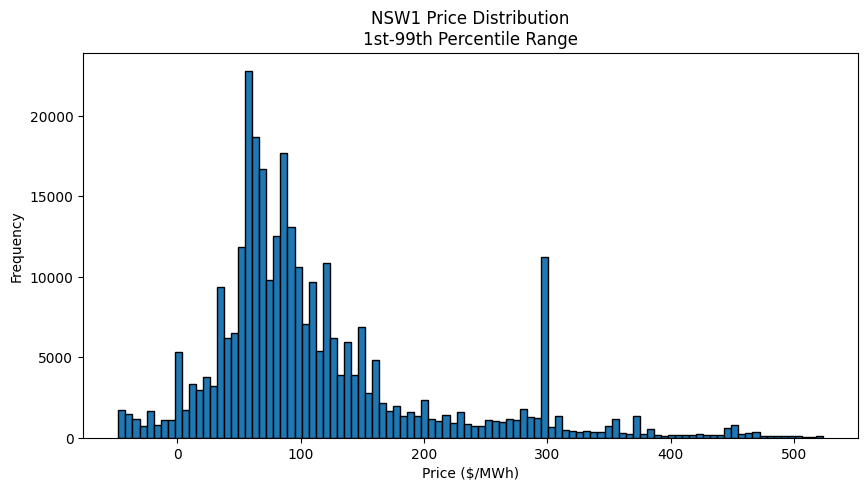

In [130]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
plt.figure(figsize=(10,5))

plt.hist(
    price_filtered['NSW1_Price'],
    bins=100,
    edgecolor='black'
)

plt.title(
    f'NSW1 Price Distribution\n'
    f'1st-99th Percentile Range'
)

plt.xlabel('Price ($/MWh)')
plt.ylabel('Frequency')

plt.show()

### NSW Wholesale Electricity Price Analysis

To better understand normal market behaviour, observations outside the 1st and 99th percentiles were excluded for visualisation purposes. This reduces the influence of extreme price spikes while retaining the underlying characteristics of the wholesale electricity market.

The filtered price distribution remains strongly right-skewed, with an average price of **$112.64/MWh** and a median price of **$88.12/MWh**. The higher mean relative to the median indicates that elevated price periods continue to pull the average upward, even after the most extreme observations have been excluded.

The distribution exhibits substantial variability, with a standard deviation of **$92.14/MWh** and an interquartile range (IQR) of **$79.50/MWh**, suggesting that wholesale prices fluctuate considerably over time. The observed price range extends from **-$47.84/MWh** to **$523.38/MWh**, highlighting the ability of the market to experience both negative pricing events and periods of significantly elevated prices.

The positive skewness (**1.51**) indicates that high-price events occur more frequently than low-price events, while the kurtosis value (**5.41**) suggests heavier tails than a normal distribution. This implies that large price movements remain relatively common even after removing the most extreme observations.

Overall, the price distribution is consistent with expected wholesale electricity market behaviour, where prices respond dynamically to changing supply and demand conditions. These characteristics are particularly relevant for Task 2, as periods of elevated demand, reduced renewable generation, or system stress may result in disproportionately larger price impacts from additional data-centre electricity demand.



### Key takeaway for Task 2

The most important conclusion is not that prices are non-normal.

The important conclusion is:

Wholesale electricity prices are highly variable, positively skewed, and prone to elevated price events, suggesting that the impact of additional data-centre demand is likely to be non-uniform and potentially much larger during stressed market conditions than during normal operating periods.

In [132]:
q90 = df_full_days['NSW1_Price'].quantile(0.90)
q95 = df_full_days['NSW1_Price'].quantile(0.95)
q99 = df_full_days['NSW1_Price'].quantile(0.99)

df_full_days['HighPriceFlag'] = df_full_days['NSW1_Price'] >= q95

In [133]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
market_condition_summary = df_full_days.groupby('HighPriceFlag').agg({
    'NSW1_Price': ['count', 'mean', 'median', 'min', 'max'],
    'NSW1_Demand': ['mean', 'median'],
    'solar_dispatch': ['mean', 'median'],
    'wind_dispatch': ['mean', 'median'],
    'hydro_dispatch': ['mean', 'median']
})

market_condition_summary

NSW1_Price                                                 \
                   count        mean     median        min          max   
HighPriceFlag                                                             
False             299244   99.110669   84.98000 -999.99906    310.89908   
True               15828  640.599914  388.02055  310.91000  16600.00000   

               NSW1_Demand         solar_dispatch            wind_dispatch  \
                      mean  median           mean     median          mean   
HighPriceFlag                                                                
False          7447.523635  7334.2     658.396876  16.725901    671.563041   
True           9284.177319  9224.6     258.728711   0.003056    738.543020   

                          hydro_dispatch              
                   median           mean      median  
HighPriceFlag                                         
False          607.125705     369.851726  278.906790  
True           607.825566     888.473270  747.988055

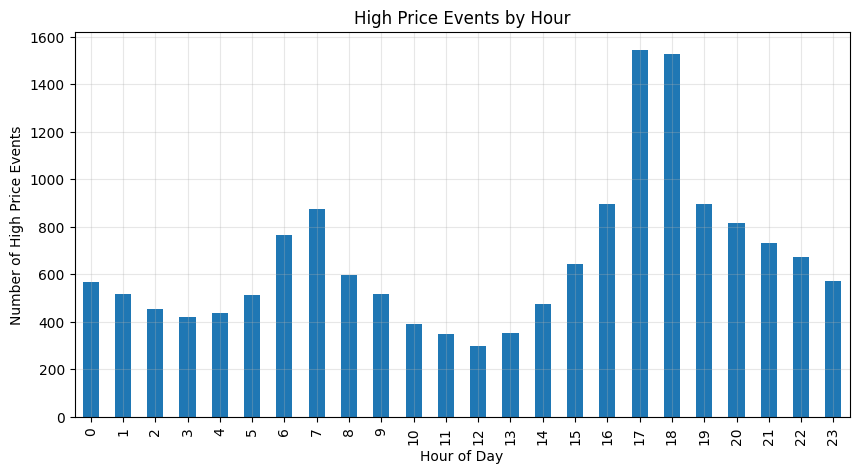

In [134]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
high_price_by_hour = df_full_days[df_full_days['HighPriceFlag']].groupby('Hour').size()

high_price_by_hour.plot(kind='bar', figsize=(10, 5))
plt.title('High Price Events by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of High Price Events')
plt.grid(True, alpha=0.3)
plt.show()

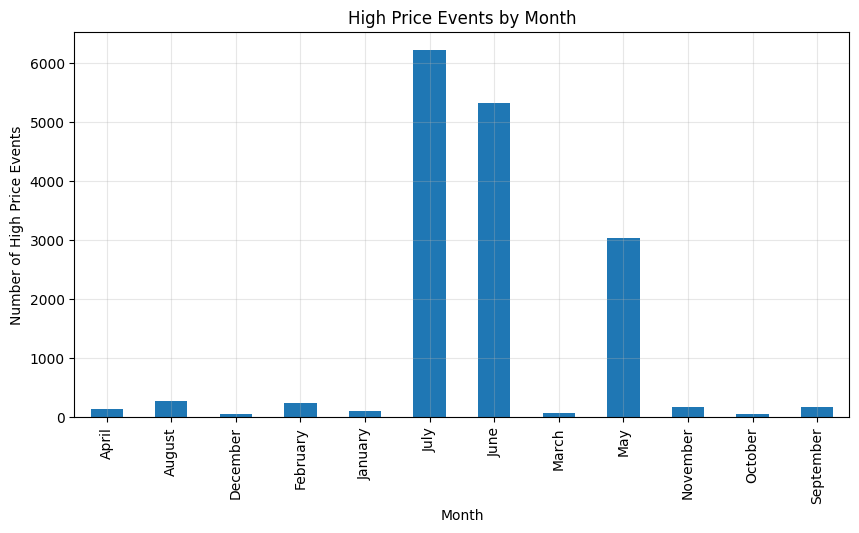

In [135]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
high_price_by_month = df_full_days[df_full_days['HighPriceFlag']].groupby('MonthName').size()

high_price_by_month.plot(kind='bar', figsize=(10, 5))
plt.title('High Price Events by Month')
plt.xlabel('Month')
plt.ylabel('Number of High Price Events')
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 800x500 with 0 Axes>

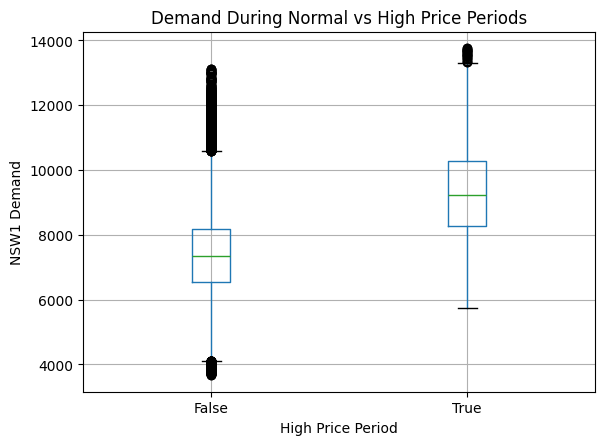

In [136]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
plt.figure(figsize=(8, 5))
df_full_days.boxplot(column='NSW1_Demand', by='HighPriceFlag')
plt.title('Demand During Normal vs High Price Periods')
plt.suptitle('')
plt.xlabel('High Price Period')
plt.ylabel('NSW1 Demand')
plt.show()

### Key Findings from High-Price Period Analysis

The analysis shows that high-price periods occur under very different market conditions compared to normal periods. Average demand during high-price intervals is approximately **9,284 MW**, compared to **7,447 MW** during normal periods, indicating that elevated demand is a major contributor to wholesale price increases.

Solar generation is substantially lower during high-price periods. While average solar dispatch falls from approximately **658 MW** to **259 MW**, the median solar dispatch during high-price intervals is effectively zero. This suggests that many high-price events occur during evening and night-time periods when solar generation is unavailable.

The hourly analysis confirms this observation, with high-price events heavily concentrated between **5 PM and 6 PM**. This period coincides with rising residential electricity demand and declining solar generation, creating tighter supply-demand conditions within the electricity market.

Seasonal analysis further shows that high-price events are most common during **May, June, and July**, indicating that winter and late autumn conditions play an important role. Increased heating demand, shorter daylight hours, and lower solar generation are likely contributing factors.

Hydro generation is significantly higher during high-price periods, increasing from an average of approximately **370 MW** to **888 MW**. This suggests that hydro generators respond to elevated prices by supplying additional generation during periods of market stress.

### Implications for Task 2

These findings suggest that future data-centre demand is unlikely to affect electricity prices uniformly throughout the day or year. The largest price impacts are likely to occur during **high-demand, low-solar periods**, particularly during **winter evenings** when the electricity system is already under stress. Consequently, time of day, seasonality, demand levels, and renewable generation availability should all be incorporated into the subsequent price-impact modelling framework.

## understanding relationship bw Price and Demand

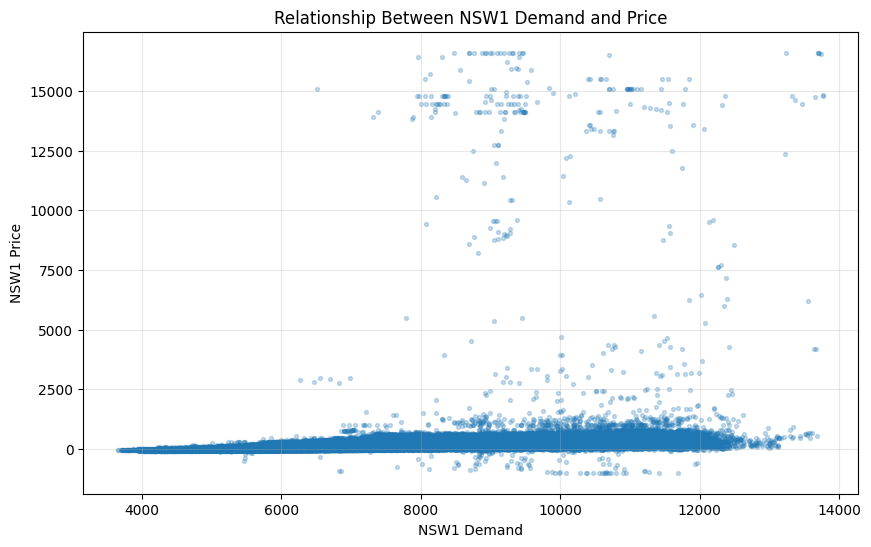

In [137]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
from scipy.stats import pearsonr, spearmanr

plt.figure(figsize=(10, 6))

plt.scatter(
    df_full_days['NSW1_Demand'],
    df_full_days['NSW1_Price'],
    alpha=0.25,
    s=8
)

plt.title('Relationship Between NSW1 Demand and Price')
plt.xlabel('NSW1 Demand')
plt.ylabel('NSW1 Price')
plt.grid(True, alpha=0.3)
plt.show()

In [138]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
pearson_corr, pearson_p = pearsonr(
    df_full_days['NSW1_Demand'],
    df_full_days['NSW1_Price']
)

spearman_corr, spearman_p = spearmanr(
    df_full_days['NSW1_Demand'],
    df_full_days['NSW1_Price']
)

print("Pearson correlation:", pearson_corr)
print("Pearson p-value:", pearson_p)
print("Spearman correlation:", spearman_corr)
print("Spearman p-value:", spearman_p)

Pearson correlation: 0.20106752855535842
Pearson p-value: 0.0
Spearman correlation: 0.5385574382128152
Spearman p-value: 0.0


In [140]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
df_full_days['Demand_Quantile_Group'] = pd.qcut(
    df_full_days['NSW1_Demand'],
    q=4,
    labels=['Low Demand', 'Medium-Low Demand', 'Medium-High Demand', 'High Demand']
)

demand_price_summary = df_full_days.groupby('Demand_Quantile_Group').agg({
    'NSW1_Demand': ['min', 'mean', 'max'],
    'NSW1_Price': ['mean', 'median', 'min', 'max', 'std']
})

demand_price_summary

NSW1_Demand                         NSW1_Price  \
                              min         mean       max        mean   
Demand_Quantile_Group                                                  
Low Demand                3664.34  6020.668960   6591.38   55.057682   
Medium-Low Demand         6591.40  7006.547788   7397.60   94.854276   
Medium-High Demand        7397.61  7809.663650   8286.28  124.787673   
High Demand               8286.30  9322.348681  13763.96  230.556181   

                                                                    
                           median        min       max         std  
Demand_Quantile_Group                                               
Low Demand              56.990000 -508.90599  15100.00   81.918158  
Medium-Low Demand       77.030720 -908.48763  14100.00  100.258744  
Medium-High Demand      91.969960 -839.73356  16432.34  247.149833  
High Demand            142.993035 -999.99906  16600.00  701.035067

In [141]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
print(demand_price_summary)

                      NSW1_Demand                         NSW1_Price  \
                              min         mean       max        mean   
Demand_Quantile_Group                                                  
Low Demand                3664.34  6020.668960   6591.38   55.057682   
Medium-Low Demand         6591.40  7006.547788   7397.60   94.854276   
Medium-High Demand        7397.61  7809.663650   8286.28  124.787673   
High Demand               8286.30  9322.348681  13763.96  230.556181   

                                                                    
                           median        min       max         std  
Demand_Quantile_Group                                               
Low Demand              56.990000 -508.90599  15100.00   81.918158  
Medium-Low Demand       77.030720 -908.48763  14100.00  100.258744  
Medium-High Demand      91.969960 -839.73356  16432.34  247.149833  
High Demand            142.993035 -999.99906  16600.00  701.035067  


In [143]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
correlation_by_demand_group = (
    df_full_days
    .groupby('Demand_Quantile_Group')
    .apply(lambda g: g['NSW1_Demand'].corr(g['NSW1_Price']))
    .reset_index(name='Correlation')
)

correlation_by_demand_group

,Demand_Quantile_Group,Correlation
0,Low Demand,0.369924
1,Medium-Low Demand,0.085793
2,Medium-High Demand,0.051909
3,High Demand,0.123628


### Key Findings from Demandâ€“Price Analysis

The demand-price analysis confirms that electricity demand is an important driver of wholesale prices, but it is not sufficient to explain price behaviour on its own.

The Pearson correlation coefficient of **0.20** indicates a relatively weak linear relationship between demand and price. However, the Spearman correlation coefficient of **0.54** suggests a stronger monotonic relationship, meaning that prices generally tend to increase as demand increases, even though the relationship is not strictly linear.

Analysis across demand quartiles reveals a clear upward trend in both average and median prices. Mean prices increase from approximately **$55/MWh** in low-demand periods to **$231/MWh** in high-demand periods, while median prices rise from approximately **$57/MWh** to **$143/MWh**. This indicates that higher demand levels are consistently associated with higher wholesale electricity prices.

Price volatility also increases substantially during high-demand periods. The standard deviation of prices in the highest demand quartile is significantly larger than in lower demand groups, indicating that price spikes are much more common when demand is elevated.

However, the relatively weak within-group correlations suggest that demand alone cannot fully explain extreme price events. Once demand reaches a certain level, other market conditions become increasingly important. These factors may include renewable generation availability, generator dispatch patterns, network constraints, fuel costs, and supply-side limitations.

### Implications for Task 2

These findings suggest that future wholesale price impacts from data-centre demand growth should not be modelled using demand alone. While additional demand is likely to increase prices, particularly during already high-demand periods, the magnitude of the impact will also depend on renewable generation availability and broader market conditions.

Consequently, the subsequent modelling framework should incorporate not only demand, but also solar generation, wind generation, hydro dispatch, seasonality, and time-of-day effects. This is particularly important because previous analysis showed that the highest prices occur during winter evening periods characterised by high demand and low solar generation.

## Understanding the relationship b/w renewable energy dispatch and RRP

In [144]:
renewable_cols = ['solar_dispatch', 'wind_dispatch', 'hydro_dispatch']
price_col = 'NSW1_Price'

In [145]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Calculate correlations between each renewable dispatch variable and price
renewable_price_corr = []

for col in renewable_cols:
    pearson_corr, pearson_p = pearsonr(df_full_days[col], df_full_days[price_col])
    spearman_corr, spearman_p = spearmanr(df_full_days[col], df_full_days[price_col])
    
    renewable_price_corr.append({
        'Variable': col,
        'Pearson Corr': pearson_corr,
        'Pearson p-value': pearson_p,
        'Spearman Corr': spearman_corr,
        'Spearman p-value': spearman_p
    })

renewable_price_corr = pd.DataFrame(renewable_price_corr)

renewable_price_corr

,Variable,Pearson Corr,Pearson p-value,Spearman Corr,Spearman p-value
0,solar_dispatch,-0.106138,0.000000e+00,-0.429255,0.000000e+00
1,wind_dispatch,-0.022191,1.269579e-35,-0.060081,9.221372e-250
2,hydro_dispatch,0.233739,0.000000e+00,0.380471,0.000000e+00


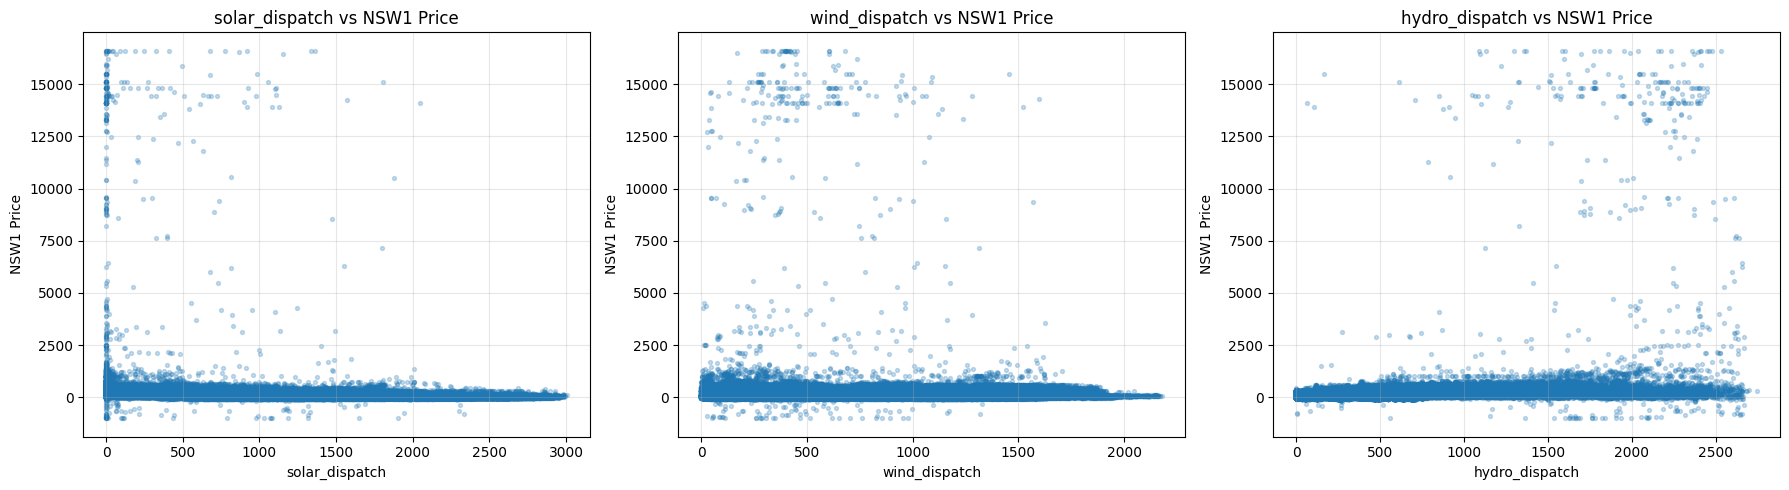

In [146]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# scatter plots to visualize relationship
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, renewable_cols):
    ax.scatter(
        df_full_days[col],
        df_full_days[price_col],
        alpha=0.25,
        s=8
    )
    ax.set_title(f'{col} vs NSW1 Price')
    ax.set_xlabel(col)
    ax.set_ylabel('NSW1 Price')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# renewable output quantile grps
for col in renewable_cols:
    group_col = col + '_Group'
    
    df_full_days[group_col] = pd.qcut(
        df_full_days[col],
        q=4,
        labels=['Low', 'Medium-Low', 'Medium-High', 'High'],
        duplicates='drop'
    )


In [148]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# price summary by renewable output quantile grps

for col in renewable_cols:
    group_col = col + '_Group'
    
    summary = df_full_days.groupby(group_col).agg({
        col: ['min', 'mean', 'max'],
        'NSW1_Price': ['mean', 'median', 'min', 'max', 'std']
    })
    
    print(f"\nPrice summary by {col} group")
    display(summary)


Price summary by solar_dispatch group


solar_dispatch                            NSW1_Price  \
                                min         mean          max        mean   
solar_dispatch_Group                                                        
Low                        0.000000     0.003814     0.018056  171.872690   
Medium-Low                 0.018066     0.389960     8.849016  126.748239   
Medium-High                8.853166   665.582592  1311.246210  144.444028   
High                    1311.296904  1887.305066  3005.506787   61.595247   

                                                                 
                         median        min      max         std  
solar_dispatch_Group                                             
Low                   120.02000 -908.48763  15500.0  308.015701  
Medium-Low             88.88000 -999.99759  16599.9  486.433295  
Medium-High            91.96000 -999.99575  16600.0  475.894285  
High                   57.93167 -999.99906  16600.0  153.267325


Price summary by wind_dispatch group


wind_dispatch                            NSW1_Price  \
                              min         mean          max        mean   
wind_dispatch_Group                                                       
Low                      0.000000   176.380270   323.305683  131.442787   
Medium-Low             323.305752   460.601696   607.187919  139.814703   
Medium-High            607.188132   788.325411   984.295241  122.406032   
High                   984.299060  1274.404048  2178.544036  111.588464   

                                                                    
                        median        min          max         std  
wind_dispatch_Group                                                 
Low                  88.638065 -999.99906  16600.00000  392.812512  
Medium-Low           92.431610 -999.99594  16600.00000  492.013092  
Medium-High          88.880205 -999.99403  16599.89028  364.059793  
High                 77.045245 -814.82499  15500.00000  238.453080


Price summary by hydro_dispatch group


hydro_dispatch                          NSW1_Price  \
                                min        mean         max        mean   
hydro_dispatch_Group                                                      
Low                         0.00000   57.019577   112.35536   76.571722   
Medium-Low                112.35545  190.120779   300.00375   91.228136   
Medium-High               300.00760  430.199940   576.81752  115.496316   
High                      576.82800  906.280780  2745.65161  221.955813   

                                                                      
                          median        min          max         std  
hydro_dispatch_Group                                                  
Low                    67.827755 -814.82499  14100.00000   89.401880  
Medium-Low             70.828615 -508.90599  15500.00000   92.602776  
Medium-High            89.000000 -999.99906   2964.03805  100.136476  
High                  134.020000 -999.99759  16600.00000  739.360203

In [150]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# compare renewable output during HIgh vs normal price periods

q95 = df_full_days['NSW1_Price'].quantile(0.95)

df_full_days['HighPriceFlag'] = df_full_days['NSW1_Price'] >= q95

renewable_high_price_summary = df_full_days.groupby('HighPriceFlag')[renewable_cols + ['NSW1_Price']].agg(
    ['mean', 'median', 'min', 'max', 'std']
)

renewable_high_price_summary

solar_dispatch                                           \
                        mean     median  min          max         std   
HighPriceFlag                                                           
False             658.396876  16.725901  0.0  3005.506787  830.389196   
True              258.728711   0.003056  0.0  2863.520387  465.328539   

              wind_dispatch                                                \
                       mean      median      min          max         std   
HighPriceFlag                                                               
False            671.563041  607.125705  0.00000  2178.544036  425.422663   
True             738.543020  607.825566  0.08317  1886.132868  501.836171   

              hydro_dispatch                                           \
                        mean      median  min         max         std   
HighPriceFlag                                                           
False             369.851726  278.906790  0.0  2745.65161  349.118304   
True              888.473270  747.988055  0.0  2700.35593  545.125455   

               NSW1_Price                                                  
                     mean     median        min          max          std  
HighPriceFlag                                                              
False           99.110669   84.98000 -999.99906    310.89908    76.075539  
True           640.599914  388.02055  310.91000  16600.00000  1590.452666

In [151]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
print(renewable_high_price_summary)

              solar_dispatch                                           \
                        mean     median  min          max         std   
HighPriceFlag                                                           
False             658.396876  16.725901  0.0  3005.506787  830.389196   
True              258.728711   0.003056  0.0  2863.520387  465.328539   

              wind_dispatch                                                \
                       mean      median      min          max         std   
HighPriceFlag                                                               
False            671.563041  607.125705  0.00000  2178.544036  425.422663   
True             738.543020  607.825566  0.08317  1886.132868  501.836171   

              hydro_dispatch                                           \
                        mean      median  min         max         std   
HighPriceFlag                                                           
False             369.851726 

In [152]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
solar_price_corr_by_hour = []

for hour, group in df_full_days.groupby('Hour'):
    pearson_corr, pearson_p = pearsonr(group['solar_dispatch'], group['NSW1_Price'])
    spearman_corr, spearman_p = spearmanr(group['solar_dispatch'], group['NSW1_Price'])
    
    solar_price_corr_by_hour.append({
        'Hour': hour,
        'Pearson Corr': pearson_corr,
        'Pearson p-value': pearson_p,
        'Spearman Corr': spearman_corr,
        'Spearman p-value': spearman_p,
        'Mean Solar': group['solar_dispatch'].mean(),
        'Mean Price': group['NSW1_Price'].mean()
    })

solar_price_corr_by_hour = pd.DataFrame(solar_price_corr_by_hour)

solar_price_corr_by_hour

,Hour,Pearson Corr,Pearson p-value,Spearman Corr,Spearman p-value,Mean Solar,Mean Price
0,0,-0.001966,8.218229e-01,-0.434777,0.000000e+00,0.072652,122.139733
1,1,-0.075283,5.762411e-18,-0.386963,0.000000e+00,0.058247,113.236366
2,2,-0.063872,2.387272e-13,-0.267994,9.595406e-215,0.055267,105.994426
3,3,-0.068641,3.453860e-15,-0.394550,0.000000e+00,0.059255,103.310953
4,4,-0.067231,1.247218e-14,-0.441512,0.000000e+00,0.067947,109.115754
5,5,-0.141449,1.215791e-59,-0.427517,0.000000e+00,26.903409,119.403979
6,6,-0.159931,6.094774e-76,-0.648508,0.000000e+00,304.031687,137.053880
7,7,-0.175074,7.379495e-91,-0.668920,0.000000e+00,828.151634,129.358638
8,8,-0.181757,6.787079e-98,-0.507331,0.000000e+00,1336.353496,95.995515
9,9,-0.204421,7.316204e-124,-0.377148,0.000000e+00,1568.682727,82.108747


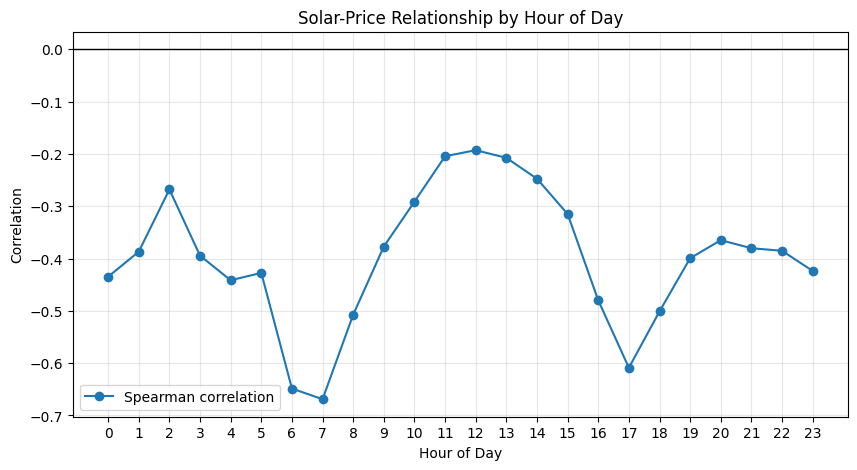

In [153]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# plotting correlation by hour
plt.figure(figsize=(10, 5))

plt.plot(
    solar_price_corr_by_hour['Hour'],
    solar_price_corr_by_hour['Spearman Corr'],
    marker='o',
    label='Spearman correlation'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Solar-Price Relationship by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Correlation')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


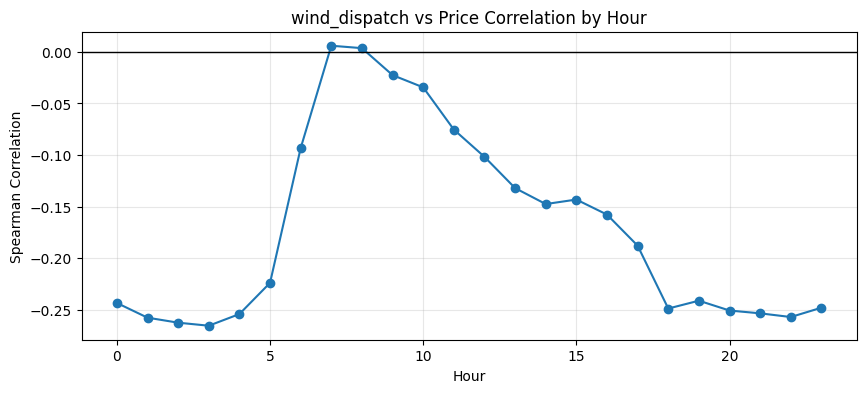

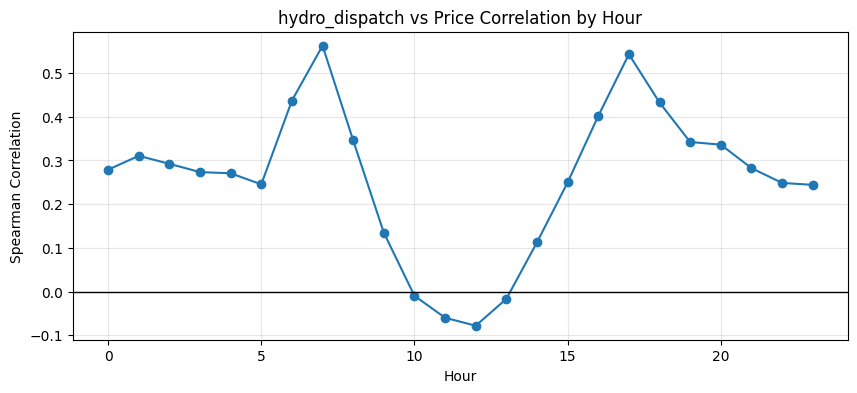

In [154]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.

for var in ['wind_dispatch', 'hydro_dispatch']:
    corr_by_hour = (
        df_full_days
        .groupby('Hour')
        .apply(lambda g: g[var].corr(g['NSW1_Price'], method='spearman'))
    )

    plt.figure(figsize=(10, 4))
    corr_by_hour.plot(marker='o')
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f'{var} vs Price Correlation by Hour')
    plt.xlabel('Hour')
    plt.ylabel('Spearman Correlation')
    plt.grid(True, alpha=0.3)
    plt.show()




### Key Findings from Renewable Output and Price Analysis

The analysis indicates that the relationship between solar generation and wholesale electricity prices varies considerably throughout the day. While solar output and prices exhibit a negative relationship across all hours, the strength of this relationship increases substantially during morning and evening transition periods.

The strongest negative correlations occur around **6 AMâ€“8 AM** and **5 PMâ€“6 PM**, with the Spearman correlation reaching approximately **-0.61** during the evening peak. This suggests that lower solar output is strongly associated with higher electricity prices during these periods.

The hourly patterns provide further evidence of this relationship. Solar generation reaches its highest levels during the middle of the day, averaging approximately **1,600 MW**, while average wholesale prices remain relatively low at around **$60â€“75/MWh**. In contrast, prices increase sharply during the late afternoon and evening as solar output declines. Average prices rise from approximately **$157/MWh** at 4 PM to **$282/MWh** at 5 PM, while solar generation falls rapidly over the same period.

These results suggest that solar generation helps suppress wholesale electricity prices during daylight hours by increasing the supply of low-cost electricity. However, the most significant market impact occurs during the evening transition period when solar output declines while electricity demand remains elevated.

Hydro output increases when prices increase.This does not mean hydro causes high prices. It's the opposite. Hydro generators are responding to:
high demand
low solar
elevated prices
by increasing generation. Hydro behaves like a flexible balancing resource.



### Implications for Task 2

The findings indicate that future data-centre demand is likely to have the greatest price impact during periods when solar generation is low, particularly during evening peak hours. Combined with earlier analysis showing that high-price events are concentrated in winter evenings and high-demand periods, the results suggest that additional demand may place disproportionate pressure on the market when renewable availability is limited.

Consequently, future price-impact modelling should explicitly account for the interaction between demand levels, solar generation, seasonality, and time of day. The evidence suggests that wholesale price impacts will be considerably larger during low-solar, high-demand periods than during daylight hours when renewable generation is abundant.

### Additional Insight from Renewable Dispatch Profiles

The evening high-price period happens exactly when solar output collapses and demand rises. Hydro increases at the same time, suggesting it is dispatched to help meet evening peak demand. Wind provides background supply but does not offset the evening solar drop strongly enough.

So the key insight is:

Solar lowers price pressure during the day, but the evening solar drop creates supply tightness. Hydro responds during this tight period, which aligns with higher market prices.


## Analyzing price by different time components

# 1. By Avg RRP

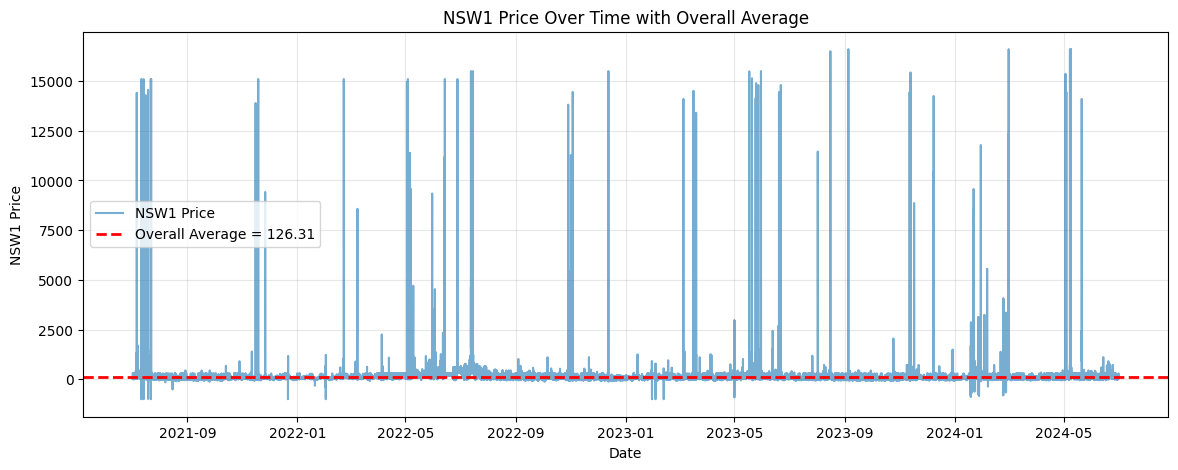

In [156]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
overall_avg_price = df_full_days['NSW1_Price'].mean()

plt.figure(figsize=(14, 5))

plt.plot(
    df_full_days['SETTLEMENTDATE'],
    df_full_days['NSW1_Price'],
    alpha=0.6,
    label='NSW1 Price'
)

plt.axhline(
    overall_avg_price,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Overall Average = {overall_avg_price:.2f}'
)

plt.title('NSW1 Price Over Time with Overall Average')
plt.xlabel('Date')
plt.ylabel('NSW1 Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Hour
0     122.139733
1     113.236366
2     105.994426
3     103.310953
4     109.115754
5     119.403979
6     137.053880
7     129.358638
8      95.995515
9      82.108747
10     70.231519
11     62.761220
12     65.604575
13     74.672226
14     92.504980
15    109.711187
16    156.713649
17    282.151595
18    276.197653
19    177.061819
20    147.481067
21    135.205212
22    136.395632
23    127.101596
Name: NSW1_Price, dtype: float64


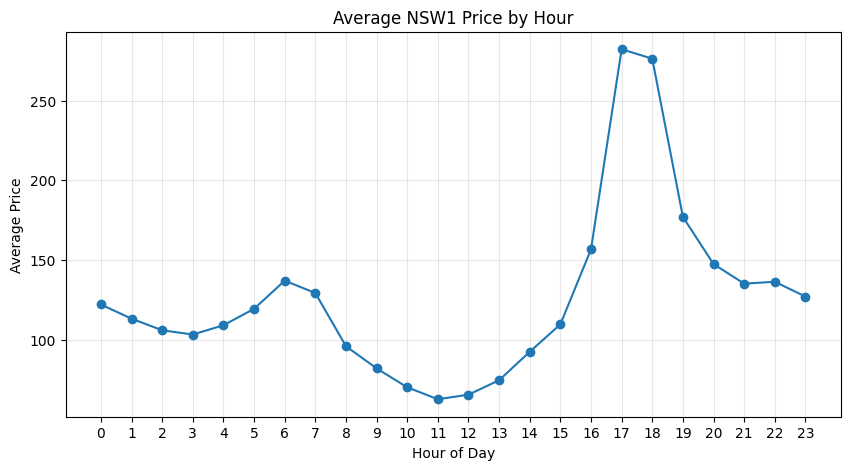

In [ ]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
#avg price by hour

avg_price_hour = df_full_days.groupby('Hour')['NSW1_Price'].mean()
avg_price_hour.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Average NSW1 Price by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()


In [158]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# avg price by day of week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_full_days['DayName'] = df_full_days['SETTLEMENTDATE'].dt.day_name()

avg_price_day = df_full_days.groupby('DayName')['NSW1_Price'].mean().reindex(day_order)

avg_price_day

DayName
Monday       129.374634
Tuesday      136.460734
Wednesday    148.467487
Thursday     139.371245
Friday       125.572176
Saturday     105.131256
Sunday       100.186500
Name: NSW1_Price, dtype: float64

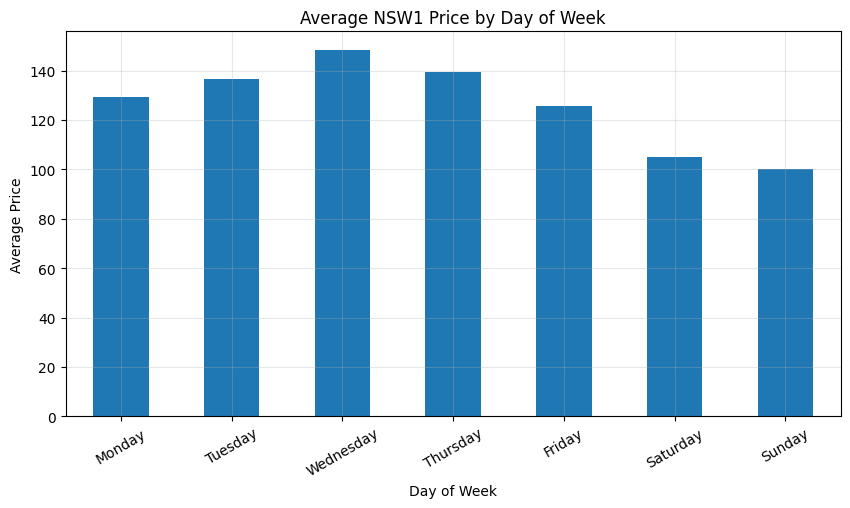

In [159]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
avg_price_day.plot(kind='bar', figsize=(10, 5))
plt.title('Average NSW1 Price by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Price')
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.show()

In [160]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# avg price by month

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

avg_price_month = df_full_days.groupby('MonthName')['NSW1_Price'].mean().reindex(month_order)

avg_price_month


MonthName
January       84.245027
February      95.139161
March         95.720049
April        129.169973
May          262.676254
June         218.663728
July         194.078382
August       100.589746
September     89.108434
October       83.615128
November      88.231951
December      72.630587
Name: NSW1_Price, dtype: float64

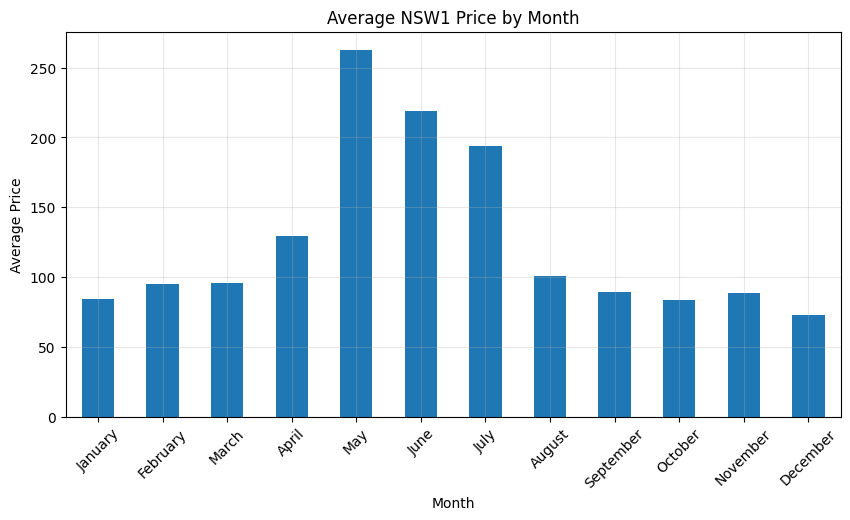

In [161]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
avg_price_month.plot(kind='bar', figsize=(10, 5))
plt.title('Average NSW1 Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

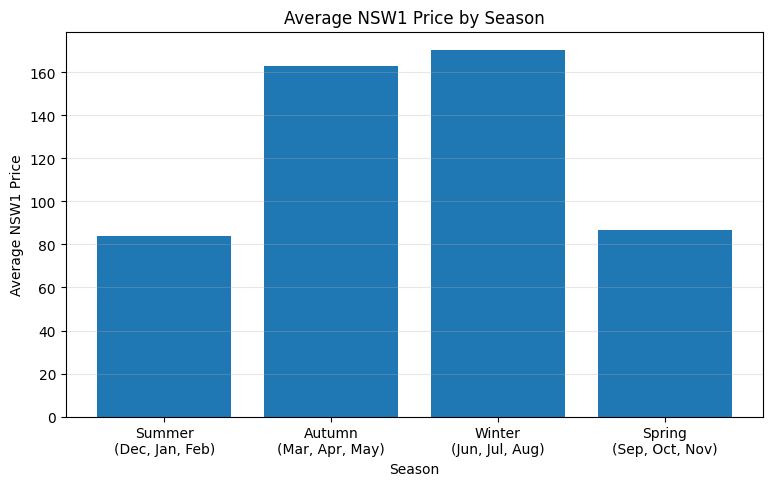

In [163]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
season_labels = {
    'Summer': 'Summer\n(Dec, Jan, Feb)',
    'Autumn': 'Autumn\n(Mar, Apr, May)',
    'Winter': 'Winter\n(Jun, Jul, Aug)',
    'Spring': 'Spring\n(Sep, Oct, Nov)'
}

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']

avg_price_season = (
    df_full_days
    .groupby('Season')['NSW1_Price']
    .mean()
    .reindex(season_order)
)

plt.figure(figsize=(9, 5))

plt.bar(
    [season_labels[s] for s in avg_price_season.index],
    avg_price_season.values
)

plt.title('Average NSW1 Price by Season')
plt.xlabel('Season')
plt.ylabel('Average NSW1 Price')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

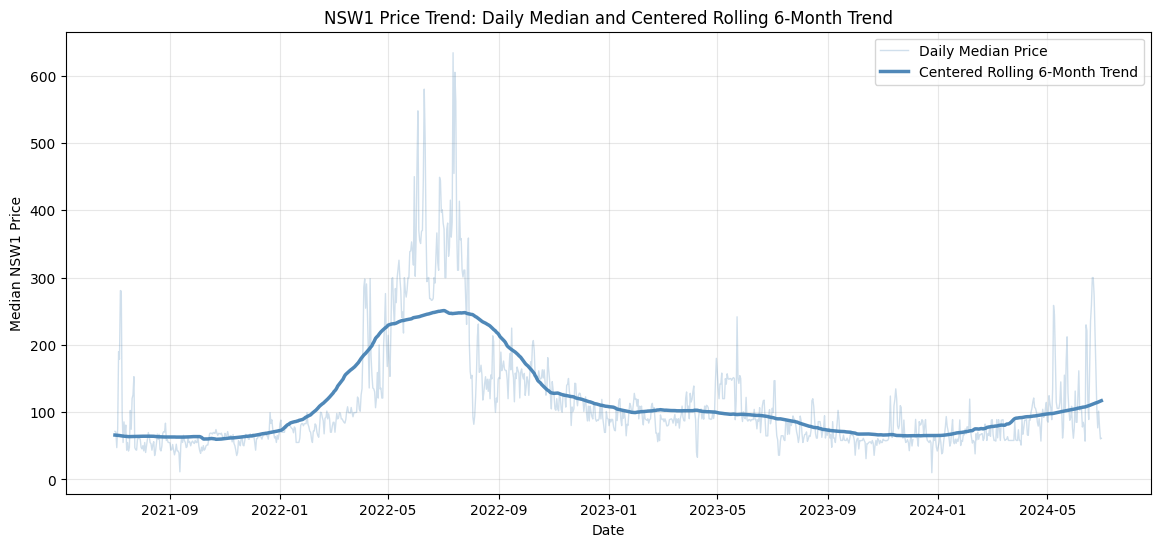

In [164]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
daily_price_median = (
    df_full_days
    .set_index('SETTLEMENTDATE')
    .resample('D')['NSW1_Price']
    .median()
)

rolling_6m_median = daily_price_median.rolling(
    window=180,
    min_periods=60,
    center=True
).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_price_median.index,
    daily_price_median,
    color='steelblue',
    alpha=0.25,
    linewidth=1,
    label='Daily Median Price'
)

plt.plot(
    rolling_6m_median.index,
    rolling_6m_median,
    color='steelblue',
    alpha=0.95,
    linewidth=2.5,
    label='Centered Rolling 6-Month Trend'
)

plt.title('NSW1 Price Trend: Daily Median and Centered Rolling 6-Month Trend')
plt.xlabel('Date')
plt.ylabel('Median NSW1 Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

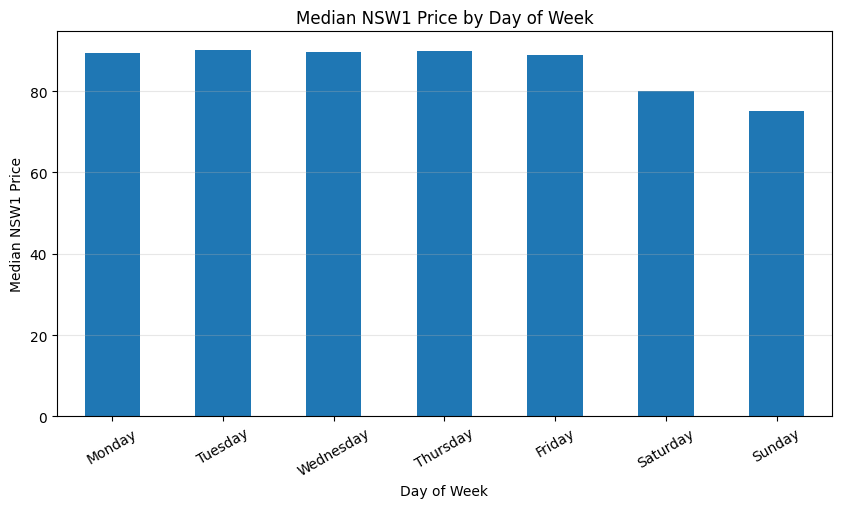

In [166]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_full_days['DayName'] = df_full_days['SETTLEMENTDATE'].dt.day_name()

median_price_day = (
    df_full_days
    .groupby('DayName')['NSW1_Price']
    .median()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
median_price_day.plot(kind='bar')

plt.title('Median NSW1 Price by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Median NSW1 Price')
plt.xticks(rotation=30)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [167]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
df_full_days.info()
# drop column Dayname
df_full_days = df_full_days.drop(columns=['DayName'])

<class 'pandas.DataFrame'>
RangeIndex: 315072 entries, 0 to 315071
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   SETTLEMENTDATE         315072 non-null  datetime64[us]
 1   NSW1_Price             315072 non-null  float64       
 2   NSW1_Demand            315072 non-null  float64       
 3   solar_dispatch         315072 non-null  float64       
 4   wind_dispatch          315072 non-null  float64       
 5   hydro_dispatch         315072 non-null  float64       
 6   Date                   315072 non-null  object        
 7   Hour                   315072 non-null  int32         
 8   DayOfWeek              315072 non-null  int32         
 9   MonthNo                315072 non-null  int32         
 10  MonthName              315072 non-null  str           
 11  Year                   315072 non-null  int32         
 12  Season                 315072 non-null  str           


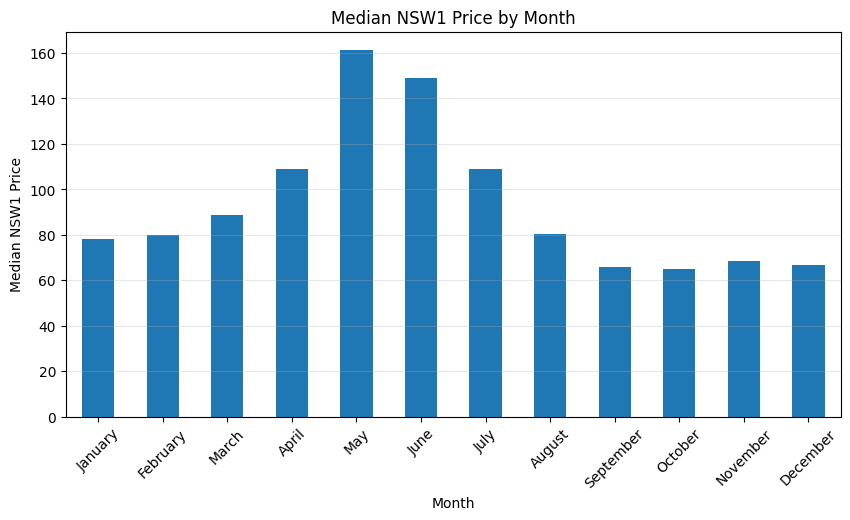

In [168]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

median_price_month = (
    df_full_days
    .groupby('MonthName')['NSW1_Price']
    .median()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))
median_price_month.plot(kind='bar')

plt.title('Median NSW1 Price by Month')
plt.xlabel('Month')
plt.ylabel('Median NSW1 Price')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

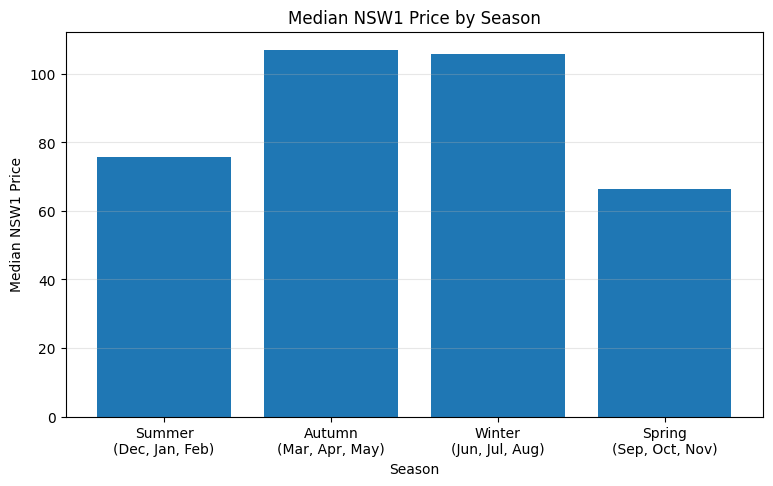

In [169]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
season_labels = {
    'Summer': 'Summer\n(Dec, Jan, Feb)',
    'Autumn': 'Autumn\n(Mar, Apr, May)',
    'Winter': 'Winter\n(Jun, Jul, Aug)',
    'Spring': 'Spring\n(Sep, Oct, Nov)'
}

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']

median_price_season = (
    df_full_days
    .groupby('Season')['NSW1_Price']
    .median()
    .reindex(season_order)
)

plt.figure(figsize=(9, 5))

plt.bar(
    [season_labels[s] for s in median_price_season.index],
    median_price_season.values
)

plt.title('Median NSW1 Price by Season')
plt.xlabel('Season')
plt.ylabel('Median NSW1 Price')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

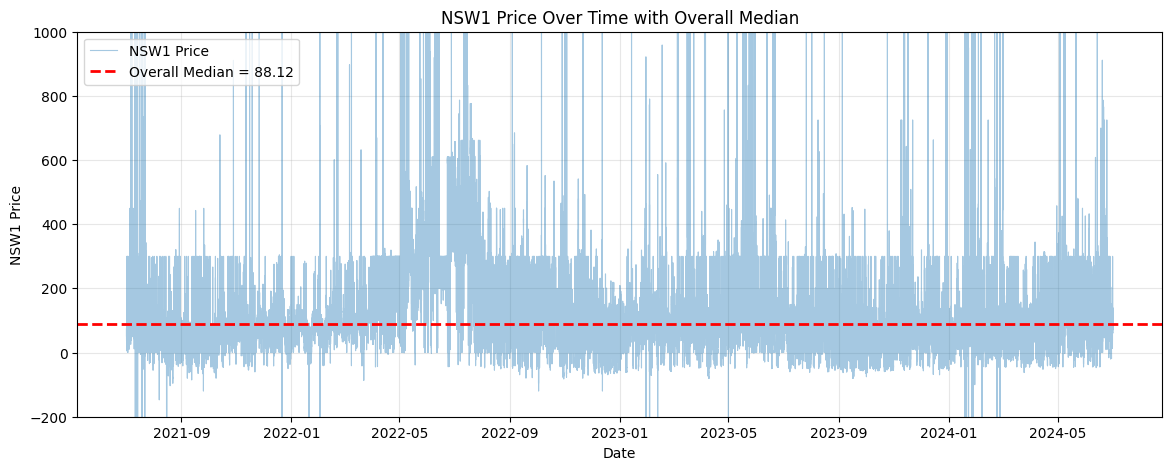

In [170]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
overall_median_price = df_full_days['NSW1_Price'].median()

plt.figure(figsize=(14, 5))

plt.plot(
    df_full_days['SETTLEMENTDATE'],
    df_full_days['NSW1_Price'],
    alpha=0.4,
    linewidth=0.8,
    label='NSW1 Price'
)

plt.axhline(
    overall_median_price,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Overall Median = {overall_median_price:.2f}'
)

plt.ylim(-200, 1000)
plt.title('NSW1 Price Over Time with Overall Median')
plt.xlabel('Date')
plt.ylabel('NSW1 Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Average vs Median Price Pattern Analysis

The average and median price visualisations show that NSW wholesale prices have both **structural price patterns** and **spike-driven volatility**. The median price is useful for understanding typical market behaviour, while the average price captures the impact of extreme price events.

Hourly analysis shows a clear evening price peak, especially around **5 PMâ€“7 PM**. Median prices rise sharply during this period, confirming that evening prices are structurally higher, not only affected by occasional spikes. The average price is even higher during these hours, indicating that price spikes are also more frequent in the evening.

Day-of-week analysis shows that weekday prices are generally higher than weekend prices. This suggests that stronger weekday demand contributes to higher wholesale prices, while weekends tend to experience lower underlying price pressure.

Monthly and seasonal analysis shows that **May, June, and July** have the highest prices. Both average and median prices are elevated in late autumn and winter, confirming that these periods are genuinely more expensive rather than being driven only by outliers. This may reflect higher heating demand, shorter daylight hours, lower solar availability, and tighter supply conditions.

The time-series analysis also shows that 2022 was a major high-price period. The average price is strongly affected by extreme spikes, while the median and rolling median trend reveal the underlying increase in market prices more clearly.

Overall, the analysis confirms that the highest-risk periods are **weekday winter evenings**, when demand is high and solar output is low. For Task 2, this means that additional data-centre demand is unlikely to affect prices evenly across all periods. The price-impact model should therefore include **hour of day, season, day type, demand, solar, wind, and hydro dispatch** as explanatory variables.

### Background Context: System Stress Analysis

The earlier exploratory analysis showed that NSW wholesale electricity prices do not increase evenly across all market conditions. High-price periods were most strongly associated with a combination of **high electricity demand**, **low solar output**, and **evening peak timing**, particularly during **autumn and winter months**.

This matters for Task 2 because additional data-centre demand is expected to add relatively steady load to the NSW electricity system. However, the price impact of this extra demand is unlikely to be the same in every period. Adding extra demand during low-stress periods, such as midday when solar output is high, may have a smaller price effect. In contrast, adding the same demand during evening periods when solar output is falling and demand is already high may create a much larger price impact.

To capture this difference, system stress conditions are defined using a set of indicator variables. These variables identify periods of high demand, low renewable availability, evening peak exposure, and seasonal stress. This allows the later price-impact model to compare the effect of data-centre demand under normal market conditions versus stressed market conditions.

The purpose of this step is not to predict prices yet, but to create meaningful market-condition segments that can later be used for scenario comparison, sensitivity analysis, and business interpretation.

In [176]:
# ------------------------------------------------------------
# 1. Create a working copy
# ------------------------------------------------------------

df_stress = df_full_days.copy()

# ------------------------------------------------------------
# 2. Define percentile thresholds
# ------------------------------------------------------------

demand_75 = df_stress['NSW1_Demand'].quantile(0.75)
solar_25 = df_stress['solar_dispatch'].quantile(0.25)
wind_25 = df_stress['wind_dispatch'].quantile(0.25)

print("75th percentile demand:", demand_75)
print("25th percentile solar:", solar_25)
print("25th percentile wind:", wind_25)

# ------------------------------------------------------------
# 3. Create individual stress flags
# ------------------------------------------------------------

df_stress['HighDemandFlag'] = df_stress['NSW1_Demand'] >= demand_75

df_stress['LowSolarFlag'] = df_stress['solar_dispatch'] <= solar_25

df_stress['LowWindFlag'] = df_stress['wind_dispatch'] <= wind_25

df_stress['EveningPeakFlag'] = df_stress['Hour'].isin([17, 18, 19])

df_stress['SeasonStressFlag'] = df_stress['Season'].isin(['Autumn', 'Winter'])

# ------------------------------------------------------------
# 4. Create three system stress levels
# ------------------------------------------------------------

# Level 1: high demand only
df_stress['DemandStressFlag'] = df_stress['HighDemandFlag']

# Level 2: high demand + low solar + evening peak
df_stress['CoreSystemStressFlag'] = (
    df_stress['HighDemandFlag'] &
    df_stress['LowSolarFlag'] &
    df_stress['EveningPeakFlag']
)

# Level 3: high demand + low solar + evening peak + Autumn/Winter
df_stress['SevereSystemStressFlag'] = (
    df_stress['HighDemandFlag'] &
    df_stress['LowSolarFlag'] &
    df_stress['EveningPeakFlag'] &
    df_stress['SeasonStressFlag']
)

# ------------------------------------------------------------
# 5. Count and percentage summary for each stress level
# ------------------------------------------------------------

stress_flags = [
    'DemandStressFlag',
    'CoreSystemStressFlag',
    'SevereSystemStressFlag'
]

stress_count_summary = pd.DataFrame({
    'Stress Level': stress_flags,
    'Observations': [df_stress[flag].sum() for flag in stress_flags],
    'Percentage of Total': [
        df_stress[flag].mean() * 100 for flag in stress_flags
    ]
})

stress_count_summary

75th percentile demand: 8286.28
25th percentile solar: 0.018056
25th percentile wind: 323.30573475


,Stress Level,Observations,Percentage of Total
0,DemandStressFlag,78769,25.000317
1,CoreSystemStressFlag,7008,2.224254
2,SevereSystemStressFlag,5832,1.851005


In [177]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 6. Price summary for each stress level
# ------------------------------------------------------------

price_summary_rows = []

for flag in stress_flags:
    subset = df_stress[df_stress[flag]]
    
    price_summary_rows.append({
        'Stress Level': flag,
        'Observations': len(subset),
        'Mean Price': subset['NSW1_Price'].mean(),
        'Median Price': subset['NSW1_Price'].median(),
        'Std Dev Price': subset['NSW1_Price'].std(),
        '95th Percentile Price': subset['NSW1_Price'].quantile(0.95)
    })

stress_price_summary = pd.DataFrame(price_summary_rows)

stress_price_summary

,Stress Level,Observations,Mean Price,Median Price,Std Dev Price,95th Percentile Price
0,DemandStressFlag,78769,230.551051,142.99113,701.022212,465.900000
1,CoreSystemStressFlag,7008,356.473132,285.58157,937.525208,619.099408
2,SevereSystemStressFlag,5832,388.795190,299.99000,1023.589252,661.740000


In [179]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 8. Combined summary table
# ------------------------------------------------------------

stress_summary = (
    stress_count_summary
    .merge(stress_price_summary, on=['Stress Level', 'Observations'])
    .merge(stress_condition_summary, on='Stress Level')
)

stress_summary

,Stress Level,Observations,Percentage of Total,Mean Price,Median Price,Std Dev Price,95th Percentile Price,Average Demand,Average Solar Dispatch,Average Wind Dispatch,Average Hydro Dispatch
0,DemandStressFlag,78769,25.000317,230.551051,142.99113,701.022212,465.900000,9322.309221,394.424765,687.886527,691.035659
1,CoreSystemStressFlag,7008,2.224254,356.473132,285.58157,937.525208,619.099408,9916.502459,0.004228,705.503265,1060.192630
2,SevereSystemStressFlag,5832,1.851005,388.795190,299.99000,1023.589252,661.740000,10090.751684,0.004155,704.134876,1094.111231


### System Stress Summary Interpretation

The stress-condition analysis confirms that NSW wholesale prices increase sharply as market conditions become more constrained. Compared with the non-demand-stress baseline, where the average price is approximately **$91.57/MWh** and the median price is **$75.67/MWh**, demand-stress periods show a much higher average price of **$230.55/MWh** and median price of **$142.99/MWh**.

The impact becomes even stronger under the core system-stress condition, defined as **high demand + low solar + evening peak**. Although this condition represents only **2.22%** of all observations, the average price rises to **$356.47/MWh**, while the median price increases to **$285.58/MWh**. This indicates that prices are not only affected by occasional spikes; typical prices are also substantially higher during these stress periods.

The severe stress condition, which adds **autumn/winter seasonality**, captures only **1.85%** of observations but has the highest prices overall. The average price reaches **$388.80/MWh**, the median price is approximately **$299.99/MWh**, and the 95th percentile price rises to **$661.74/MWh**. This confirms that winter and late-autumn evening periods are the most exposed to price pressure.

The generation patterns also support the earlier analysis. Solar dispatch is almost zero during both core and severe stress periods, while hydro dispatch increases sharply from approximately **298 MW** in the non-stress baseline to more than **1,000 MW** under core and severe stress. This suggests that hydro generation is being dispatched as a flexible response to market stress rather than acting as the original cause of high prices. Wind dispatch remains relatively stable, reinforcing the earlier finding that wind is less directly linked to high-price formation than solar.

For Task 2, this confirms that additional data-centre demand should not be assessed only through an overall average price impact. The price impact is likely to be much larger during **high-demand, low-solar, evening, autumn/winter periods**. Therefore, the scenario modelling should separately report price impacts under normal, demand-stress, core-stress, and severe-stress conditions.

## Moving Towards Predictive Modelling

1. Multicollinearity Check

In [181]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# creating correlation matrix
feature_cols = [
    'NSW1_Demand',
    'solar_dispatch',
    'wind_dispatch',
    'hydro_dispatch',
    'Hour',
    'DayOfWeek',
    'MonthNo',
    'Year'
]

X_features = df_stress[feature_cols].copy()

corr_matrix = X_features.corr()

corr_matrix

,NSW1_Demand,solar_dispatch,wind_dispatch,hydro_dispatch,Hour,DayOfWeek,MonthNo,Year
NSW1_Demand,1.000000,-0.268362,0.049793,0.503312,4.365840e-01,-1.607426e-01,-1.462879e-01,3.849800e-02
solar_dispatch,-0.268362,1.000000,-0.272860,-0.226218,2.600878e-02,1.451671e-03,-3.605242e-02,1.437438e-01
wind_dispatch,0.049793,-0.272860,1.000000,-0.037531,-4.000591e-03,3.358318e-02,-1.012081e-02,-1.008344e-02
hydro_dispatch,0.503312,-0.226218,-0.037531,1.000000,2.991116e-01,-4.323772e-02,1.144015e-02,7.949105e-03
Hour,0.436584,0.026009,-0.004001,0.299112,1.000000e+00,-6.574766e-17,-3.215068e-17,5.488059e-15
DayOfWeek,-0.160743,0.001452,0.033583,-0.043238,-6.574766e-17,1.000000e+00,8.198639e-03,6.977660e-06
MonthNo,-0.146288,-0.036052,-0.010121,0.011440,-3.215068e-17,8.198639e-03,1.000000e+00,-4.560021e-01
Year,0.038498,0.143744,-0.010083,0.007949,5.488059e-15,6.977660e-06,-4.560021e-01,1.000000e+00


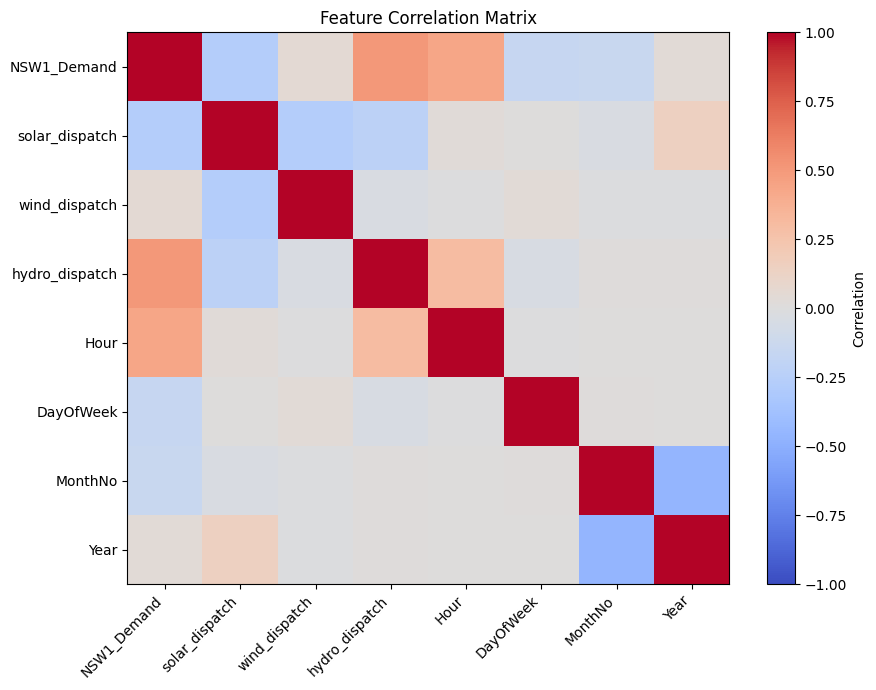

In [182]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# correlation heatmap

plt.figure(figsize=(9, 7))

plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [183]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# VIF Checks
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = X_features.dropna().copy()

vif_table = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table.sort_values('VIF', ascending=False)


,Feature,VIF
7,Year,65.910908
0,NSW1_Demand,58.496267
4,Hour,4.916724
6,MonthNo,4.767047
2,wind_dispatch,3.798837
5,DayOfWeek,3.388372
3,hydro_dispatch,2.936066
1,solar_dispatch,1.981303


2. encoding variables, creating modelling df, train-test split

In [187]:
# ------------------------------------------------------------
# 1. Define target and modelling features
# ------------------------------------------------------------

target = 'NSW1_Price'

features = [
    'NSW1_Demand',
    'solar_dispatch',
    'wind_dispatch',
    'hydro_dispatch',
    'Hour',
    'DayOfWeek',
    'MonthNo',
    'Season',
    'DayType',
    'DemandStressFlag',
    'CoreSystemStressFlag',
    'SevereSystemStressFlag'
]

# ------------------------------------------------------------
# 2. Create modelling dataframe
# Do not modify df_full_days or df_stress directly
# SETTLEMENTDATE is kept only for sorting and time split
# ------------------------------------------------------------

model_df = df_stress[
    ['SETTLEMENTDATE'] + features + [target]
].copy()

# ------------------------------------------------------------
# 3. Sort by timestamp for time-series modelling
# ------------------------------------------------------------

model_df = model_df.sort_values('SETTLEMENTDATE').reset_index(drop=True)

print("model_df shape:", model_df.shape)

# ------------------------------------------------------------
# 4. One-hot encode categorical columns
# ------------------------------------------------------------

categorical_cols = [
    'Season',
    'DayType'  
]

model_encoded = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

# ------------------------------------------------------------
# 5. Convert boolean stress flags to integers
# ------------------------------------------------------------

bool_cols = [
    'DemandStressFlag',
    'CoreSystemStressFlag',
    'SevereSystemStressFlag'
]

model_encoded[bool_cols] = model_encoded[bool_cols].astype(int)

print("encoded dataframe shape:", model_encoded.shape)

# ------------------------------------------------------------
# 6. Time-based train-test split
# Training: before 2024-01-01
# Testing: 2024-01-01 onwards
# ------------------------------------------------------------

split_date = pd.Timestamp("2024-01-01")

train_df = model_encoded[
    model_encoded['SETTLEMENTDATE'] < split_date
].copy()

test_df = model_encoded[
    model_encoded['SETTLEMENTDATE'] >= split_date
].copy()

# ------------------------------------------------------------
# 7. Create X and y
# SETTLEMENTDATE is removed from features
# NSW1_Price is the target and is not included in X
# ------------------------------------------------------------

X_train = train_df.drop(columns=['SETTLEMENTDATE', target])
X_test = test_df.drop(columns=['SETTLEMENTDATE', target])

y_train = train_df[target]
y_test = test_df[target]

# ------------------------------------------------------------
# 8. Print checks
# ------------------------------------------------------------

print("model_df shape:", model_df.shape)
print("encoded dataframe shape:", model_encoded.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFinal encoded feature columns:")
print(list(X_train.columns))

print("\nFirst few rows of X_train:")
display(X_train.head())

model_df shape: (315072, 14)
encoded dataframe shape: (315072, 16)
model_df shape: (315072, 14)
encoded dataframe shape: (315072, 16)
X_train shape: (262656, 14)
X_test shape: (52416, 14)
y_train shape: (262656,)
y_test shape: (52416,)

Final encoded feature columns:
['NSW1_Demand', 'solar_dispatch', 'wind_dispatch', 'hydro_dispatch', 'Hour', 'DayOfWeek', 'MonthNo', 'DemandStressFlag', 'CoreSystemStressFlag', 'SevereSystemStressFlag', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'DayType_Weekend']

First few rows of X_train:


,NSW1_Demand,solar_dispatch,wind_dispatch,hydro_dispatch,Hour,DayOfWeek,MonthNo,DemandStressFlag,CoreSystemStressFlag,SevereSystemStressFlag,Season_Spring,Season_Summer,Season_Winter,DayType_Weekend
0,8409.13,0.068,297.48617,0.0,0,4,7,1,0,0,False,False,True,False
1,8435.62,0.068,295.00872,0.0,0,4,7,1,0,0,False,False,True,False
2,8350.73,0.068,279.04481,0.0,0,4,7,1,0,0,False,False,True,False
3,8394.72,0.068,269.34122,0.0,0,4,7,1,0,0,False,False,True,False
4,8359.33,0.068,266.51703,0.0,0,4,7,1,0,0,False,False,True,False


In [188]:
# convert the boolean/dummy columns, not the whole dataframe

bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

### Training and evaluating the performance of Multiple Linear regression

In [190]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Train Multiple Linear Regression baseline model
# ------------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = linear_model.predict(X_test)

In [191]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 2. Overall model evaluation
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

overall_lr_metrics = pd.DataFrame([
    {
        'Model': 'Multiple Linear Regression',
        **regression_metrics(y_test, y_pred_lr)
    }
])

overall_lr_metrics

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,86.82326,648.622521,0.045741


In [192]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 3. Stress-period evaluation
# ------------------------------------------------------------

def evaluate_by_stress_period(X_test, y_test, y_pred):
    
    stress_periods = {
        'Normal / Non-Demand-Stress': ~X_test['DemandStressFlag'].astype(bool),
        'Demand Stress': X_test['DemandStressFlag'].astype(bool),
        'Core System Stress': X_test['CoreSystemStressFlag'].astype(bool),
        'Severe System Stress': X_test['SevereSystemStressFlag'].astype(bool)
    }
    
    rows = []
    
    for period_name, mask in stress_periods.items():
        y_true_period = y_test[mask]
        y_pred_period = y_pred[mask]
        
        rows.append({
            'Stress Period': period_name,
            'Observations': mask.sum(),
            **regression_metrics(y_true_period, y_pred_period)
        })
    
    return pd.DataFrame(rows)

lr_stress_metrics = evaluate_by_stress_period(
    X_test,
    y_test,
    y_pred_lr
)

lr_stress_metrics

,Stress Period,Observations,MAE,RMSE,R2
0,Normal / Non-Demand-Stress,37382,51.687184,298.429460,0.027152
1,Demand Stress,15034,174.189019,1115.957239,0.033342
2,Core System Stress,913,200.925463,667.246302,0.013936
3,Severe System Stress,843,206.249788,689.533046,0.011869


The Multiple Linear Regression model was used as a transparent baseline. However, it performed weakly, with a low RÂ² and large errors during stress periods. This confirms that the demand-price relationship is not adequately captured by a simple linear model. Since wholesale electricity prices are nonlinear and spike-prone, tree-based models such as Random Forest and Gradient Boosting are required to better capture interactions between demand, renewable output, time of day, and stress conditions.

2. HistGradientBoostingRegressor

In [194]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Train HistGradientBoostingRegressor
# ------------------------------------------------------------

hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(X_train, y_train)

# Predict on test data
y_pred_hgb = hgb_model.predict(X_test)

In [195]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 2. Overall evaluation
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

hgb_overall_metrics = pd.DataFrame([
    {
        'Model': 'HistGradientBoostingRegressor',
        **regression_metrics(y_test, y_pred_hgb)
    }
])

hgb_overall_metrics

,Model,MAE,RMSE,R2
0,HistGradientBoostingRegressor,75.127269,642.186247,0.064585


In [196]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 3. Stress-period evaluation
# ------------------------------------------------------------

def evaluate_by_stress_period(X_test, y_test, y_pred):
    
    stress_periods = {
        'Normal / Non-Demand-Stress': ~X_test['DemandStressFlag'].astype(bool),
        'Demand Stress': X_test['DemandStressFlag'].astype(bool),
        'Core System Stress': X_test['CoreSystemStressFlag'].astype(bool),
        'Severe System Stress': X_test['SevereSystemStressFlag'].astype(bool)
    }
    
    rows = []
    
    for period_name, mask in stress_periods.items():
        y_true_period = y_test[mask]
        y_pred_period = y_pred[mask]
        
        rows.append({
            'Stress Period': period_name,
            'Observations': mask.sum(),
            **regression_metrics(y_true_period, y_pred_period)
        })
    
    return pd.DataFrame(rows)

hgb_stress_metrics = evaluate_by_stress_period(
    X_test,
    y_test,
    y_pred_hgb
)

hgb_stress_metrics

,Stress Period,Observations,MAE,RMSE,R2
0,Normal / Non-Demand-Stress,37382,38.730911,294.935357,0.049799
1,Demand Stress,15034,165.626713,1105.237505,0.051824
2,Core System Stress,913,122.324261,614.591322,0.163423
3,Severe System Stress,843,124.616007,634.479512,0.163358


In [198]:
# xgboost



from xgboost import XGBRegressor


xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_metrics = pd.DataFrame([{
    'Model': 'XGBoost Regressor',
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    'R2': r2_score(y_test, y_pred_xgb)
}])

xgb_metrics

,Model,MAE,RMSE,R2
0,XGBoost Regressor,78.819574,641.002037,0.068032


In [ ]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.

et_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)

et_metrics = pd.DataFrame([{
    'Model': 'Extra Trees Regressor',
    'MAE': mean_absolute_error(y_test, y_pred_et),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_et)),
    'R2': r2_score(y_test, y_pred_et)
}])

et_metrics

,Model,MAE,RMSE,R2
0,Extra Trees Regressor,80.491196,638.317127,0.075823


In [200]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 1. Cap extreme target values using training-set threshold only
# This avoids using information from the test set to define the cap.
# ------------------------------------------------------------

price_cap = y_train.quantile(0.99)

y_train_capped = y_train.clip(upper=price_cap)
y_test_capped = y_test.clip(upper=price_cap)

print("99th percentile price cap based on training data:", price_cap)
print("Original y_train max:", y_train.max())
print("Capped y_train max:", y_train_capped.max())
print("Original y_test max:", y_test.max())
print("Capped y_test max:", y_test_capped.max())

99th percentile price cap based on training data: 541.89
Original y_train max: 16599.89
Capped y_train max: 541.89
Original y_test max: 16600.0
Capped y_test max: 541.89


In [201]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 2. Train Extra Trees Regressor on capped target
# ------------------------------------------------------------

et_capped_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

et_capped_model.fit(X_train, y_train_capped)

# Predict capped price target
y_pred_et_capped = et_capped_model.predict(X_test)

In [202]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 3. Overall evaluation against capped test target
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

et_capped_metrics = pd.DataFrame([
    {
        'Model': 'Extra Trees Regressor - 99% Capped Target',
        **regression_metrics(y_test_capped, y_pred_et_capped)
    }
])

et_capped_metrics

,Model,MAE,RMSE,R2
0,Extra Trees Regressor - 99% Capped Target,46.045096,67.688335,0.361991


In [203]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 4. Stress-period evaluation using capped target
# ------------------------------------------------------------

def evaluate_by_stress_period(X_test, y_test_eval, y_pred):
    
    stress_periods = {
        'Normal / Non-Demand-Stress': ~X_test['DemandStressFlag'].astype(bool),
        'Demand Stress': X_test['DemandStressFlag'].astype(bool),
        'Core System Stress': X_test['CoreSystemStressFlag'].astype(bool),
        'Severe System Stress': X_test['SevereSystemStressFlag'].astype(bool)
    }
    
    rows = []
    
    for period_name, mask in stress_periods.items():
        y_true_period = y_test_eval[mask]
        y_pred_period = y_pred[mask]
        
        rows.append({
            'Stress Period': period_name,
            'Observations': mask.sum(),
            **regression_metrics(y_true_period, y_pred_period)
        })
    
    return pd.DataFrame(rows)

et_capped_stress_metrics = evaluate_by_stress_period(
    X_test,
    y_test_capped,
    y_pred_et_capped
)

et_capped_stress_metrics

,Stress Period,Observations,MAE,RMSE,R2
0,Normal / Non-Demand-Stress,37382,38.361311,53.061761,0.044838
1,Demand Stress,15034,65.150808,94.727310,0.289424
2,Core System Stress,913,74.594700,98.309444,0.293019
3,Severe System Stress,843,74.718833,91.693641,0.285203


In [209]:
# ------------------------------------------------------------
# 1. Create lag-free modelling dataframe
# Remove price lag features for scenario-impact modelling
# ------------------------------------------------------------

impact_df = model_ready_df.copy().sort_values('SETTLEMENTDATE').reset_index(drop=True)

target = 'NSW1_Price'

features_impact = [
    'NSW1_Demand',
    'solar_dispatch',
    'wind_dispatch',
    'hydro_dispatch',
    'Hour',
    'DayOfWeek',
    'MonthNo',
    'Season',
    'DayType',
    'DemandStressFlag',
    'CoreSystemStressFlag',
    'SevereSystemStressFlag',
    'NSW1_Demand_lag1',
    'Total_Renewable_Dispatch',
    'Net_Demand'
]

impact_model_df = impact_df[['SETTLEMENTDATE'] + features_impact + [target]].copy()

impact_encoded = pd.get_dummies(
    impact_model_df,
    columns=['Season', 'DayType'],
    drop_first=True
)

bool_cols = impact_encoded.select_dtypes(include='bool').columns
impact_encoded[bool_cols] = impact_encoded[bool_cols].astype(int)

impact_encoded.head()

,SETTLEMENTDATE,NSW1_Demand,solar_dispatch,wind_dispatch,hydro_dispatch,Hour,DayOfWeek,MonthNo,DemandStressFlag,CoreSystemStressFlag,SevereSystemStressFlag,NSW1_Demand_lag1,Total_Renewable_Dispatch,Net_Demand,NSW1_Price,Season_Spring,Season_Summer,Season_Winter,DayType_Weekend
0,2021-07-02 01:00:00,8099.55,0.069,188.15006,0.0,1,4,7,0,0,0,8143.31,188.21906,7911.33094,57.37000,0,0,1,0
1,2021-07-02 01:05:00,8014.51,0.069,173.70866,0.0,1,4,7,0,0,0,8099.55,173.77766,7840.73234,57.37000,0,0,1,0
2,2021-07-02 01:10:00,7980.60,0.069,165.13600,0.0,1,4,7,0,0,0,8014.51,165.20500,7815.39500,55.53159,0,0,1,0
3,2021-07-02 01:15:00,7926.88,0.069,172.31793,0.0,1,4,7,0,0,0,7980.60,172.38693,7754.49307,54.85190,0,0,1,0
4,2021-07-02 01:20:00,7812.58,0.069,157.08172,0.0,1,4,7,0,0,0,7926.88,157.15072,7655.42928,49.70278,0,0,1,0


In [210]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
impact_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 315060 entries, 0 to 315059
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SETTLEMENTDATE            315060 non-null  datetime64[us]
 1   NSW1_Demand               315060 non-null  float64       
 2   solar_dispatch            315060 non-null  float64       
 3   wind_dispatch             315060 non-null  float64       
 4   hydro_dispatch            315060 non-null  float64       
 5   Hour                      315060 non-null  int32         
 6   DayOfWeek                 315060 non-null  int32         
 7   MonthNo                   315060 non-null  int32         
 8   DemandStressFlag          315060 non-null  int64         
 9   CoreSystemStressFlag      315060 non-null  int64         
 10  SevereSystemStressFlag    315060 non-null  int64         
 11  NSW1_Demand_lag1          315060 non-null  float64       
 12  Total_Renewab

In [211]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 2. Time-based train-test split
# ------------------------------------------------------------

split_date = pd.Timestamp("2024-01-01")

train_impact = impact_encoded[impact_encoded['SETTLEMENTDATE'] < split_date].copy()
test_impact = impact_encoded[impact_encoded['SETTLEMENTDATE'] >= split_date].copy()

X_train_impact = train_impact.drop(columns=['SETTLEMENTDATE', target])
X_test_impact = test_impact.drop(columns=['SETTLEMENTDATE', target])

y_train_impact = train_impact[target]
y_test_impact = test_impact[target]

print("X_train_impact:", X_train_impact.shape)
print("X_test_impact:", X_test_impact.shape)
print("Features:", list(X_train_impact.columns))



X_train_impact: (262644, 17)
X_test_impact: (52416, 17)
Features: ['NSW1_Demand', 'solar_dispatch', 'wind_dispatch', 'hydro_dispatch', 'Hour', 'DayOfWeek', 'MonthNo', 'DemandStressFlag', 'CoreSystemStressFlag', 'SevereSystemStressFlag', 'NSW1_Demand_lag1', 'Total_Renewable_Dispatch', 'Net_Demand', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'DayType_Weekend']


In [212]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 3. Metric function
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

In [213]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 4. Train uncapped XGBoost model
# This keeps all extreme price observations
# ------------------------------------------------------------

xgb_impact_uncapped = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_impact_uncapped.fit(X_train_impact, y_train_impact)

y_pred_uncapped = xgb_impact_uncapped.predict(X_test_impact)

uncapped_metrics = pd.DataFrame([{
    'Model': 'XGBoost Impact Model - Uncapped',
    **regression_metrics(y_test_impact, y_pred_uncapped)
}])

uncapped_metrics

,Model,MAE,RMSE,R2
0,XGBoost Impact Model - Uncapped,78.629749,645.662413,0.054431


In [214]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 5. Capping sensitivity runs
# Caps are based on training data only to avoid test leakage
# ------------------------------------------------------------

cap_thresholds = {
    'p99': y_train_impact.quantile(0.99),
    'p99.5': y_train_impact.quantile(0.995),
    'p99.9': y_train_impact.quantile(0.999),
    '$1000/MWh': 1000
}

sensitivity_results = []
sensitivity_models = {}


for cap_name, cap_value in cap_thresholds.items():
    
    y_train_capped = y_train_impact.clip(upper=cap_value)
    y_test_capped = y_test_impact.clip(upper=cap_value)
    
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_impact, y_train_capped)
    y_pred = model.predict(X_test_impact)
    
    sensitivity_models[cap_name] = model
    
    sensitivity_results.append({
        'Cap': cap_name,
        'Cap_Value': cap_value,
        **regression_metrics(y_test_capped, y_pred)
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

sensitivity_results

,Cap,Cap_Value,MAE,RMSE,R2
0,p99,541.890000,40.465776,62.157006,0.462003
1,p99.5,638.487879,41.068227,64.542703,0.454991
2,p99.9,1188.183900,43.057819,80.890412,0.395027
3,$1000/MWh,1000.000000,42.591058,74.730189,0.417174


Final Modelling Approach
use a lag-free XGBoost scenario-impact model because the goal is not short-term forecasting, but estimating the price effect of extra data-centre demand. Price lag features were excluded to avoid anchoring predictions to historical prices and suppressing the demand-impact channel.


In [215]:
# ------------------------------------------------------------
# 1. Scenario table: 15 scenario-year combinations
# ------------------------------------------------------------

scenario_table = pd.DataFrame({
    'FY': ['FY2026', 'FY2027', 'FY2028', 'FY2029', 'FY2030'] * 3,
    'Scenario': (
        ['Slower Growth'] * 5 +
        ['Step Change'] * 5 +
        ['Accelerated Transition'] * 5
    ),
    'Additional_DC_MW': [
        45.66, 91.32, 136.99, 194.06, 262.56,
        79.91, 182.65, 296.80, 445.21, 639.27,
        114.16, 273.97, 502.28, 799.09, 1221.46
    ]
})

scenario_table

,FY,Scenario,Additional_DC_MW
0,FY2026,Slower Growth,45.66
1,FY2027,Slower Growth,91.32
2,FY2028,Slower Growth,136.99
3,FY2029,Slower Growth,194.06
4,FY2030,Slower Growth,262.56
5,FY2026,Step Change,79.91
6,FY2027,Step Change,182.65
7,FY2028,Step Change,296.80
8,FY2029,Step Change,445.21
9,FY2030,Step Change,639.27


In [216]:
# ------------------------------------------------------------
# 1. Create lag-free base dataframe
# Do not overwrite model_ready_df
# Drop only price-lag features
# ------------------------------------------------------------

impact_base_df = model_ready_df.drop(
    columns=[
        'NSW1_Price_lag1',
        'NSW1_Price_roll_1hr'
    ]
).copy()

impact_base_df = impact_base_df.sort_values('SETTLEMENTDATE').reset_index(drop=True)

print("impact_base_df shape:", impact_base_df.shape)
impact_base_df.head()

impact_base_df shape: (315060, 17)


,SETTLEMENTDATE,NSW1_Demand,solar_dispatch,wind_dispatch,hydro_dispatch,Hour,DayOfWeek,MonthNo,Season,DayType,DemandStressFlag,CoreSystemStressFlag,SevereSystemStressFlag,NSW1_Demand_lag1,Total_Renewable_Dispatch,Net_Demand,NSW1_Price
0,2021-07-02 01:00:00,8099.55,0.069,188.15006,0.0,1,4,7,Winter,Weekday,False,False,False,8143.31,188.21906,7911.33094,57.37000
1,2021-07-02 01:05:00,8014.51,0.069,173.70866,0.0,1,4,7,Winter,Weekday,False,False,False,8099.55,173.77766,7840.73234,57.37000
2,2021-07-02 01:10:00,7980.60,0.069,165.13600,0.0,1,4,7,Winter,Weekday,False,False,False,8014.51,165.20500,7815.39500,55.53159
3,2021-07-02 01:15:00,7926.88,0.069,172.31793,0.0,1,4,7,Winter,Weekday,False,False,False,7980.60,172.38693,7754.49307,54.85190
4,2021-07-02 01:20:00,7812.58,0.069,157.08172,0.0,1,4,7,Winter,Weekday,False,False,False,7926.88,157.15072,7655.42928,49.70278


In [217]:
# ------------------------------------------------------------
# 2. Define target and lag-free feature list
# ------------------------------------------------------------

target = 'NSW1_Price'

features_impact = [
    'NSW1_Demand',
    'solar_dispatch',
    'wind_dispatch',
    'hydro_dispatch',
    'Hour',
    'DayOfWeek',
    'MonthNo',
    'Season',
    'DayType',
    'DemandStressFlag',
    'CoreSystemStressFlag',
    'SevereSystemStressFlag',
    'NSW1_Demand_lag1',
    'Total_Renewable_Dispatch',
    'Net_Demand'
]

In [218]:
# ------------------------------------------------------------
# 3. Encode categorical features
# Preserve float columns and convert bools/dummies to 1/0
# ------------------------------------------------------------

impact_model_df = impact_base_df[
    ['SETTLEMENTDATE'] + features_impact + [target]
].copy()

impact_encoded = pd.get_dummies(
    impact_model_df,
    columns=['Season', 'DayType'],
    drop_first=True
)

bool_cols = impact_encoded.select_dtypes(include='bool').columns
impact_encoded[bool_cols] = impact_encoded[bool_cols].astype(int)

print("impact_encoded shape:", impact_encoded.shape)
impact_encoded.head()

impact_encoded shape: (315060, 19)


,SETTLEMENTDATE,NSW1_Demand,solar_dispatch,wind_dispatch,hydro_dispatch,Hour,DayOfWeek,MonthNo,DemandStressFlag,CoreSystemStressFlag,SevereSystemStressFlag,NSW1_Demand_lag1,Total_Renewable_Dispatch,Net_Demand,NSW1_Price,Season_Spring,Season_Summer,Season_Winter,DayType_Weekend
0,2021-07-02 01:00:00,8099.55,0.069,188.15006,0.0,1,4,7,0,0,0,8143.31,188.21906,7911.33094,57.37000,0,0,1,0
1,2021-07-02 01:05:00,8014.51,0.069,173.70866,0.0,1,4,7,0,0,0,8099.55,173.77766,7840.73234,57.37000,0,0,1,0
2,2021-07-02 01:10:00,7980.60,0.069,165.13600,0.0,1,4,7,0,0,0,8014.51,165.20500,7815.39500,55.53159,0,0,1,0
3,2021-07-02 01:15:00,7926.88,0.069,172.31793,0.0,1,4,7,0,0,0,7980.60,172.38693,7754.49307,54.85190,0,0,1,0
4,2021-07-02 01:20:00,7812.58,0.069,157.08172,0.0,1,4,7,0,0,0,7926.88,157.15072,7655.42928,49.70278,0,0,1,0


In [219]:
# ------------------------------------------------------------
# 4. Time-based train-test split
# ------------------------------------------------------------

split_date = pd.Timestamp("2024-01-01")

train_impact = impact_encoded[impact_encoded['SETTLEMENTDATE'] < split_date].copy()
test_impact = impact_encoded[impact_encoded['SETTLEMENTDATE'] >= split_date].copy()

X_train_impact = train_impact.drop(columns=['SETTLEMENTDATE', target])
X_test_impact = test_impact.drop(columns=['SETTLEMENTDATE', target])

y_train_impact = train_impact[target]
y_test_impact = test_impact[target]

print("X_train_impact shape:", X_train_impact.shape)
print("X_test_impact shape:", X_test_impact.shape)
print("y_train_impact shape:", y_train_impact.shape)
print("y_test_impact shape:", y_test_impact.shape)

X_train_impact shape: (262644, 17)
X_test_impact shape: (52416, 17)
y_train_impact shape: (262644,)
y_test_impact shape: (52416,)


In [220]:
# ------------------------------------------------------------
# 5. Train capped XGBoost sensitivity models
# Caps are based on training data only
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

cap_thresholds = {
    'p99': y_train_impact.quantile(0.99),
    'p99.5': y_train_impact.quantile(0.995),
    'p99.9': y_train_impact.quantile(0.999),
    '$1000/MWh': 1000
}

impact_models = {}
impact_model_metrics = []

for cap_name, cap_value in cap_thresholds.items():
    
    y_train_capped = y_train_impact.clip(upper=cap_value)
    y_test_capped = y_test_impact.clip(upper=cap_value)
    
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_impact, y_train_capped)
    
    y_pred = model.predict(X_test_impact)
    
    impact_models[cap_name] = model
    
    impact_model_metrics.append({
        'Cap_Model': cap_name,
        'Cap_Value': cap_value,
        **regression_metrics(y_test_capped, y_pred)
    })

impact_model_metrics = pd.DataFrame(impact_model_metrics)

impact_model_metrics

,Cap_Model,Cap_Value,MAE,RMSE,R2
0,p99,541.890000,40.465776,62.157006,0.462003
1,p99.5,638.487879,41.068227,64.542703,0.454991
2,p99.9,1188.183900,43.057819,80.890412,0.395027
3,$1000/MWh,1000.000000,42.591058,74.730189,0.417174


In [221]:
# ------------------------------------------------------------
# 7. Historical thresholds and helper functions
# ------------------------------------------------------------

demand_q75 = impact_base_df['NSW1_Demand'].quantile(0.75)
solar_q25 = impact_base_df['solar_dispatch'].quantile(0.25)

variable_renewable_dispatch = (
    impact_base_df['solar_dispatch'] + impact_base_df['wind_dispatch']
)

low_renewable_q25 = variable_renewable_dispatch.quantile(0.25)

def classify_period(hour):
    if hour in [17, 18, 19]:
        return 'Peak'
    elif hour in list(range(7, 17)) + [20, 21, 22]:
        return 'Shoulder'
    else:
        return 'Off-peak'

def prepare_impact_features(df, feature_columns):
    
    encoded = pd.get_dummies(
        df,
        columns=['Season', 'DayType'],
        drop_first=True
    )
    
    bool_cols = encoded.select_dtypes(include='bool').columns
    encoded[bool_cols] = encoded[bool_cols].astype(int)
    
    X = encoded.drop(columns=['SETTLEMENTDATE', 'NSW1_Price'], errors='ignore')
    
    X = X.reindex(columns=feature_columns, fill_value=0)
    
    return X

In [222]:
# ------------------------------------------------------------
# 8. Run 15 scenario predictions for each capped model
# Only update columns affected by additional demand
# ------------------------------------------------------------

all_scenario_results = []

for cap_name, model in impact_models.items():
    
    X_base = prepare_impact_features(
        impact_base_df.copy(),
        X_train_impact.columns
    )
    
    baseline_pred = model.predict(X_base)
    
    for _, row in scenario_table.iterrows():
        
        scenario = row['Scenario']
        fy = row['FY']
        additional_mw = row['Additional_DC_MW']
        
        scenario_df = impact_base_df.copy()
        
        # Add additional data-centre demand
        scenario_df['NSW1_Demand'] = scenario_df['NSW1_Demand'] + additional_mw
        
        # Update existing demand lag feature
        scenario_df['NSW1_Demand_lag1'] = scenario_df['NSW1_Demand_lag1'] + additional_mw
        
        # Update existing net demand feature
        scenario_df['Net_Demand'] = (
            scenario_df['NSW1_Demand'] -
            scenario_df['solar_dispatch'] -
            scenario_df['wind_dispatch']
        )
        
        # Recalculate stress flags affected by higher demand
        low_solar_flag = scenario_df['solar_dispatch'] <= solar_q25
        evening_peak_flag = scenario_df['Hour'].isin([17, 18, 19])
        season_stress_flag = scenario_df['Season'].isin(['Autumn', 'Winter'])
        
        scenario_df['DemandStressFlag'] = scenario_df['NSW1_Demand'] >= demand_q75
        
        scenario_df['CoreSystemStressFlag'] = (
            scenario_df['DemandStressFlag'] &
            low_solar_flag &
            evening_peak_flag
        )
        
        scenario_df['SevereSystemStressFlag'] = (
            scenario_df['CoreSystemStressFlag'] &
            season_stress_flag
        )
        
        # Context columns for reporting only
        scenario_df['Variable_Renewable_Dispatch'] = (
            scenario_df['solar_dispatch'] + scenario_df['wind_dispatch']
        )
        
        scenario_df['LowRenewableFlag'] = (
            scenario_df['Variable_Renewable_Dispatch'] <= low_renewable_q25
        )
        
        scenario_df['PeakPeriod'] = scenario_df['Hour'].apply(classify_period)
        
        X_scenario = prepare_impact_features(
            scenario_df,
            X_train_impact.columns
        )
        
        scenario_pred = model.predict(X_scenario)
        
        result = scenario_df[
            [
                'SETTLEMENTDATE',
                'Hour',
                'Season',
                'DayType',
                'PeakPeriod',
                'LowRenewableFlag',
                'DemandStressFlag',
                'CoreSystemStressFlag',
                'SevereSystemStressFlag'
            ]
        ].copy()
        
        result['Cap_Model'] = cap_name
        result['Cap_Value'] = cap_thresholds[cap_name]
        result['Scenario'] = scenario
        result['FY'] = fy
        result['Additional_DC_MW'] = additional_mw
        result['Baseline_Predicted_Price'] = baseline_pred
        result['Scenario_Predicted_Price'] = scenario_pred
        result['Price_Impact'] = scenario_pred - baseline_pred
        
        all_scenario_results.append(result)

scenario_impact_results = pd.concat(all_scenario_results, ignore_index=True)

scenario_impact_results.head()

,SETTLEMENTDATE,Hour,Season,DayType,PeakPeriod,LowRenewableFlag,DemandStressFlag,CoreSystemStressFlag,SevereSystemStressFlag,Cap_Model,Cap_Value,Scenario,FY,Additional_DC_MW,Baseline_Predicted_Price,Scenario_Predicted_Price,Price_Impact
0,2021-07-02 01:00:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,96.525063,100.069603,3.544540
1,2021-07-02 01:05:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,96.754066,97.946106,1.192039
2,2021-07-02 01:10:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,89.491791,97.689873,8.198082
3,2021-07-02 01:15:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,87.508080,89.491791,1.983711
4,2021-07-02 01:20:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,81.434944,84.269844,2.834900


In [223]:
# ------------------------------------------------------------
# 9. Percentile-based summary function
# ------------------------------------------------------------

def impact_summary(df, group_cols):
    return (
        df
        .groupby(group_cols)
        .agg(
            Observations=('Price_Impact', 'count'),
            Mean_Impact=('Price_Impact', 'mean'),
            Median_Impact=('Price_Impact', 'median'),
            P75_Impact=('Price_Impact', lambda x: x.quantile(0.75)),
            P95_Impact=('Price_Impact', lambda x: x.quantile(0.95))
        )
        .reset_index()
    )

In [224]:
# ------------------------------------------------------------
# 10. Required impact summaries
# ------------------------------------------------------------

overall_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'Additional_DC_MW']
)

hour_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'Hour']
)

peak_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'PeakPeriod']
)

daytype_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'DayType']
)

season_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'Season']
)

low_renewable_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'LowRenewableFlag']
)

demand_stress_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'DemandStressFlag']
)

core_stress_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'CoreSystemStressFlag']
)

severe_stress_summary = impact_summary(
    scenario_impact_results,
    ['Cap_Model', 'Scenario', 'FY', 'SevereSystemStressFlag']
)

overall_summary.head()

,Cap_Model,Scenario,FY,Additional_DC_MW,Observations,Mean_Impact,Median_Impact,P75_Impact,P95_Impact
0,$1000/MWh,Accelerated Transition,FY2026,114.16,315060,3.588178,2.661528,5.173586,11.539244
1,$1000/MWh,Accelerated Transition,FY2027,273.97,315060,8.604431,6.892527,11.809561,23.637976
2,$1000/MWh,Accelerated Transition,FY2028,502.28,315060,15.774676,12.847955,21.458679,41.058167
3,$1000/MWh,Accelerated Transition,FY2029,799.09,315060,25.163673,20.887878,34.512596,63.238483
4,$1000/MWh,Accelerated Transition,FY2030,1221.46,315060,39.031582,33.007133,54.463028,95.284607


In [225]:
# ------------------------------------------------------------
# 11. Optional exports
# ------------------------------------------------------------

scenario_impact_results.to_csv("scenario_impact_results.csv", index=False)
overall_summary.to_csv("overall_summary_lagfree.csv", index=False)
hour_summary.to_csv("hour_summary_lagfree.csv", index=False)
peak_summary.to_csv("peak_summary_lagfree.csv", index=False)
daytype_summary.to_csv("daytype_summary_lagfree.csv", index=False)
season_summary.to_csv("season_summary_lagfree.csv", index=False)
low_renewable_summary.to_csv("low_renewable_summary_lagfree.csv", index=False)
demand_stress_summary.to_csv("demand_stress_summary_lagfree.csv", index=False)
core_stress_summary.to_csv("core_stress_summary_lagfree.csv", index=False)
severe_stress_summary.to_csv("severe_stress_summary_lagfree.csv", index=False)

print("All lag-free scenario outputs exported.")

All lag-free scenario outputs exported.


## To better understand the effect of Low Renewable periods on Prices

1. Low renewable + DemandStressFlag
2. Low renewable + PeakPeriod
3. Low renewable + SevereSystemStressFlag

In [228]:
# ------------------------------------------------------------
# 1. Filter to p99 results only
# ------------------------------------------------------------

p99_results = scenario_impact_results[
    scenario_impact_results['Cap_Model'] == 'p99'
].copy()

# Make readable renewable label
p99_results['Renewable_Period'] = np.where(
    p99_results['LowRenewableFlag'] == True,
    'Low renewable',
    'Normal renewable'
)

In [229]:
# ------------------------------------------------------------
# 2. Helper function for impact summaries
# ------------------------------------------------------------

def impact_summary(df, group_cols):
    return (
        df
        .groupby(group_cols)
        .agg(
            Observations=('Price_Impact', 'count'),
            Mean_Impact=('Price_Impact', 'mean'),
            Median_Impact=('Price_Impact', 'median'),
            P75_Impact=('Price_Impact', lambda x: x.quantile(0.75)),
            P95_Impact=('Price_Impact', lambda x: x.quantile(0.95))
        )
        .reset_index()
    )

In [230]:
# ------------------------------------------------------------
# 3. Low renewable + DemandStressFlag High demand only
# ------------------------------------------------------------

lowrenew_demandstress_summary = impact_summary(
    p99_results,
    [
        'Scenario',
        'FY',
        'Renewable_Period',
        'DemandStressFlag'
    ]
)

lowrenew_demandstress_summary

,Scenario,FY,Renewable_Period,DemandStressFlag,Observations,Mean_Impact,Median_Impact,P75_Impact,P95_Impact
0,Accelerated Transition,FY2026,Low renewable,False,50383,2.725890,2.111397,3.774612,8.091131
1,Accelerated Transition,FY2026,Low renewable,True,28382,4.060251,2.752625,6.545261,16.316832
2,Accelerated Transition,FY2026,Normal renewable,False,177734,3.615508,2.824743,5.083054,10.222045
3,Accelerated Transition,FY2026,Normal renewable,True,58561,3.416133,2.491455,6.280090,15.213760
4,Accelerated Transition,FY2027,Low renewable,False,47192,6.400417,5.409206,8.375076,15.659224
5,Accelerated Transition,FY2027,Low renewable,True,31573,9.541739,8.045280,14.979706,29.841412
6,Accelerated Transition,FY2027,Normal renewable,False,168429,8.651977,7.197033,11.696114,20.611071
7,Accelerated Transition,FY2027,Normal renewable,True,67866,8.210387,6.797760,13.978491,28.551617
8,Accelerated Transition,FY2028,Low renewable,False,42361,11.656677,10.215660,14.904381,26.722603
9,Accelerated Transition,FY2028,Low renewable,True,36404,17.060366,15.199928,25.548437,47.124752


In [231]:
# ------------------------------------------------------------
# 4. Low renewable + PeakPeriod
# ------------------------------------------------------------

lowrenew_peak_summary = impact_summary(
    p99_results,
    [
        'Scenario',
        'FY',
        'Renewable_Period',
        'PeakPeriod'
    ]
)

lowrenew_peak_summary

,Scenario,FY,Renewable_Period,PeakPeriod,Observations,Mean_Impact,Median_Impact,P75_Impact,P95_Impact
0,Accelerated Transition,FY2026,Low renewable,Off-peak,43058,2.982760,2.153090,4.063999,9.482616
1,Accelerated Transition,FY2026,Low renewable,Peak,15585,3.914381,2.542221,6.043167,16.216925
2,Accelerated Transition,FY2026,Low renewable,Shoulder,20122,3.137821,2.333359,4.524788,11.727670
3,Accelerated Transition,FY2026,Normal renewable,Off-peak,61954,3.089375,2.284286,4.171455,9.466181
4,Accelerated Transition,FY2026,Normal renewable,Peak,23799,2.815510,1.991028,4.778408,12.481282
...,...,...,...,...,...,...,...,...,...
85,Step Change,FY2030,Low renewable,Peak,15585,20.480841,18.592010,30.956299,56.511963
86,Step Change,FY2030,Low renewable,Shoulder,20122,18.184908,15.329613,24.611019,52.237484
87,Step Change,FY2030,Normal renewable,Off-peak,61954,16.908510,13.649223,22.122988,40.825985
88,Step Change,FY2030,Normal renewable,Peak,23799,16.117188,12.864594,25.213051,48.714375


In [232]:
# ------------------------------------------------------------
# 5. Low renewable + SevereSystemStressFlag (High Demand + Low Solar + Evening Peak + Autumn/winter)
# ------------------------------------------------------------

lowrenew_severestress_summary = impact_summary(
    p99_results,
    [
        'Scenario',
        'FY',
        'Renewable_Period',
        'SevereSystemStressFlag'
    ]
)

lowrenew_severestress_summary

,Scenario,FY,Renewable_Period,SevereSystemStressFlag,Observations,Mean_Impact,Median_Impact,P75_Impact,P95_Impact
0,Accelerated Transition,FY2026,Low renewable,False,75642,3.154371,2.245365,4.445854,10.960230
1,Accelerated Transition,FY2026,Low renewable,True,3123,4.474431,2.243484,6.834572,22.532328
2,Accelerated Transition,FY2026,Normal renewable,False,233380,3.564330,2.777740,5.293276,11.321909
3,Accelerated Transition,FY2026,Normal renewable,True,2915,3.707578,1.851898,6.184517,19.040953
4,Accelerated Transition,FY2027,Low renewable,False,75546,7.549781,5.993820,10.302799,22.036045
5,Accelerated Transition,FY2027,Low renewable,True,3219,10.237351,7.572723,17.369293,38.710182
6,Accelerated Transition,FY2027,Normal renewable,False,233264,8.522093,7.130850,12.184076,22.897974
7,Accelerated Transition,FY2027,Normal renewable,True,3031,8.760321,6.359177,15.097378,31.608543
8,Accelerated Transition,FY2028,Low renewable,False,75431,13.997300,11.657875,19.029110,37.913239
9,Accelerated Transition,FY2028,Low renewable,True,3334,17.703562,15.632759,30.083897,56.232491


In [233]:
# ------------------------------------------------------------
# 6. Focus on FY2030 only for easier interpretation
# ------------------------------------------------------------

lowrenew_demandstress_2030 = lowrenew_demandstress_summary[
    lowrenew_demandstress_summary['FY'] == 'FY2030'
].copy()

lowrenew_peak_2030 = lowrenew_peak_summary[
    lowrenew_peak_summary['FY'] == 'FY2030'
].copy()

lowrenew_severestress_2030 = lowrenew_severestress_summary[
    lowrenew_severestress_summary['FY'] == 'FY2030'
].copy()

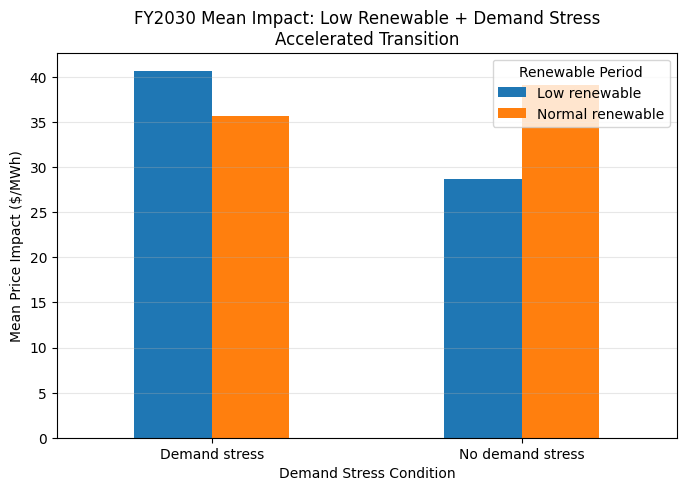

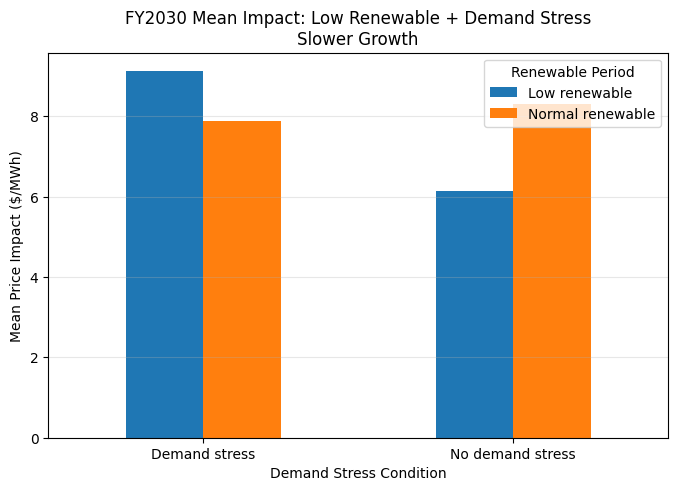

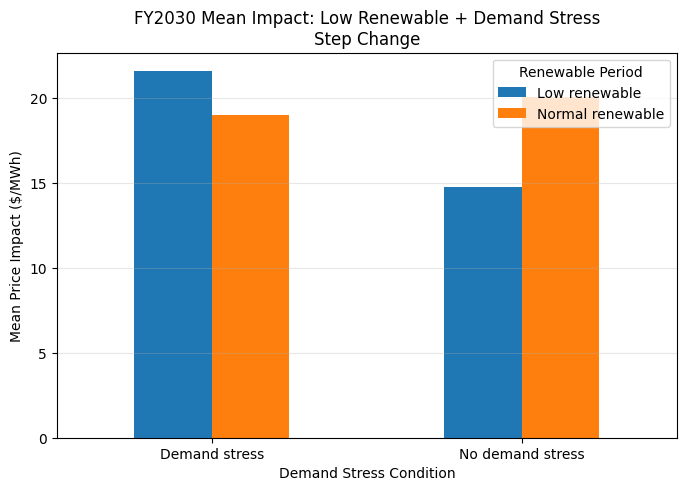

In [237]:
# ------------------------------------------------------------
# 7. Plot: FY2030 low renewable + demand stress
# ------------------------------------------------------------

plot_df = lowrenew_demandstress_2030.copy()

plot_df['DemandStressLabel'] = np.where(
    plot_df['DemandStressFlag'] == True,
    'Demand stress',
    'No demand stress'
)

for scenario in plot_df['Scenario'].unique():
    
    scenario_plot = plot_df[plot_df['Scenario'] == scenario]
    
    pivot = scenario_plot.pivot_table(
        index='DemandStressLabel',
        columns='Renewable_Period',
        values='Mean_Impact'
    )
    
    pivot.plot(kind='bar', figsize=(8, 5))
    
    plt.title(f'FY2030 Mean Impact: Low Renewable + Demand Stress\n{scenario}')
    plt.xlabel('Demand Stress Condition')
    plt.ylabel('Mean Price Impact ($/MWh)')
    plt.xticks(rotation=0)
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(title='Renewable Period')
    plt.show()

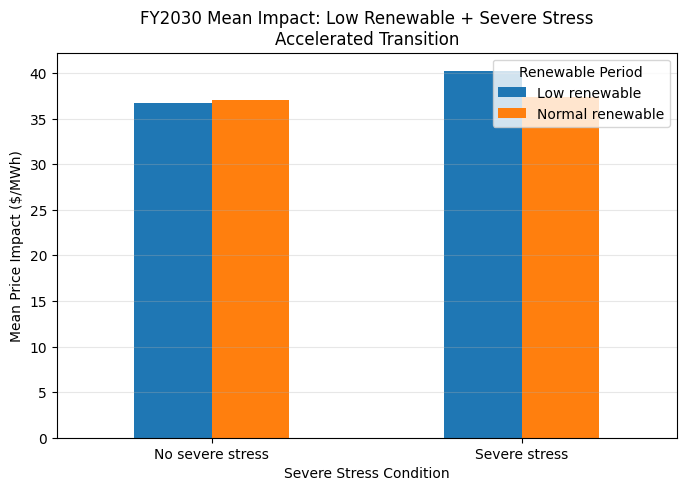

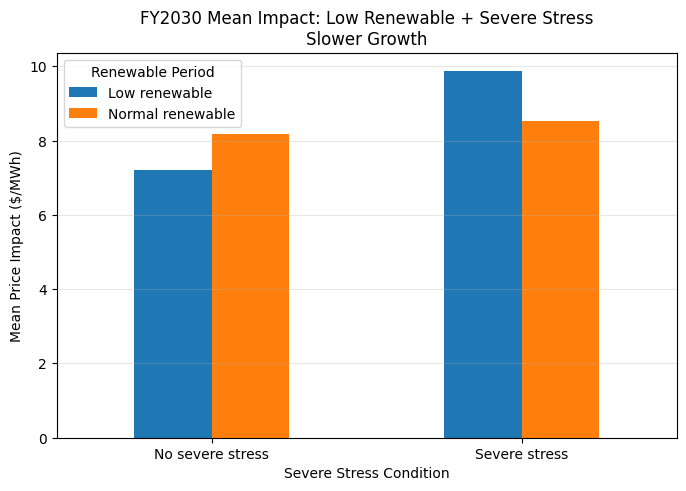

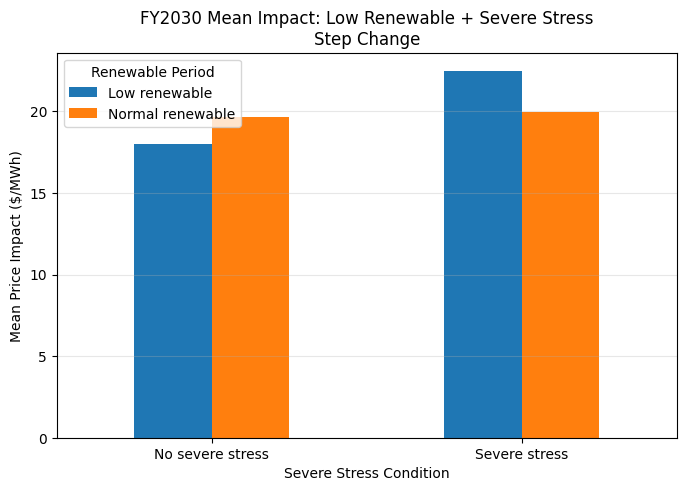

In [238]:
# ------------------------------------------------------------
# 9. Plot: FY2030 low renewable + severe stress
# ------------------------------------------------------------

plot_df = lowrenew_severestress_2030.copy()

plot_df['SevereStressLabel'] = np.where(
    plot_df['SevereSystemStressFlag'] == True,
    'Severe stress',
    'No severe stress'
)

for scenario in plot_df['Scenario'].unique():
    
    scenario_plot = plot_df[plot_df['Scenario'] == scenario]
    
    pivot = scenario_plot.pivot_table(
        index='SevereStressLabel',
        columns='Renewable_Period',
        values='Mean_Impact'
    )
    
    pivot.plot(kind='bar', figsize=(8, 5))
    
    plt.title(f'FY2030 Mean Impact: Low Renewable + Severe Stress\n{scenario}')
    plt.xlabel('Severe Stress Condition')
    plt.ylabel('Mean Price Impact ($/MWh)')
    plt.xticks(rotation=0)
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(title='Renewable Period')
    plt.show()

In [239]:
# ------------------------------------------------------------
# Low renewable + CoreSystemStressFlag analysis for p99 only
# ------------------------------------------------------------

p99_results = scenario_impact_results[
    scenario_impact_results['Cap_Model'] == 'p99'
].copy()

p99_results['Renewable_Period'] = np.where(
    p99_results['LowRenewableFlag'] == True,
    'Low renewable',
    'Normal renewable'
)

lowrenew_corestress_summary = (
    p99_results
    .groupby([
        'Scenario',
        'FY',
        'Renewable_Period',
        'CoreSystemStressFlag'
    ])
    .agg(
        Observations=('Price_Impact', 'count'),
        Mean_Impact=('Price_Impact', 'mean'),
        Median_Impact=('Price_Impact', 'median'),
        P75_Impact=('Price_Impact', lambda x: x.quantile(0.75)),
        P95_Impact=('Price_Impact', lambda x: x.quantile(0.95))
    )
    .reset_index()
)

lowrenew_corestress_summary

,Scenario,FY,Renewable_Period,CoreSystemStressFlag,Observations,Mean_Impact,Median_Impact,P75_Impact,P95_Impact
0,Accelerated Transition,FY2026,Low renewable,False,75032,3.145901,2.240513,4.429094,10.909031
1,Accelerated Transition,FY2026,Low renewable,True,3733,4.428954,2.439575,6.792114,22.024822
2,Accelerated Transition,FY2026,Normal renewable,False,232675,3.559500,2.775597,5.286892,11.300658
3,Accelerated Transition,FY2026,Normal renewable,True,3620,3.990112,2.202324,6.512581,19.283800
4,Accelerated Transition,FY2027,Low renewable,False,74869,7.532444,5.976364,10.250061,21.942631
5,Accelerated Transition,FY2027,Low renewable,True,3896,10.103487,8.065704,16.794323,36.827774
6,Accelerated Transition,FY2027,Normal renewable,False,232433,8.509855,7.121155,12.163265,22.870098
7,Accelerated Transition,FY2027,Normal renewable,True,3862,9.445545,7.829689,15.911564,30.416206
8,Accelerated Transition,FY2028,Low renewable,False,74676,13.964383,11.616043,18.948009,37.790825
9,Accelerated Transition,FY2028,Low renewable,True,4089,17.620407,15.942993,29.326218,52.884327


## Analyzing Price Level impacts hourly

In [241]:
# compare baseline price vs price impact by hour

hour_context = scenario_impact_results[
    (scenario_impact_results['Cap_Model'] == 'p99') &
    (scenario_impact_results['Scenario'] == 'Step Change') &
    (scenario_impact_results['FY'] == 'FY2030')
].copy()

hour_price_impact = (
    hour_context
    .groupby('Hour')
    .agg(
        Baseline_Price=('Baseline_Predicted_Price', 'mean'),
        Scenario_Price=('Scenario_Predicted_Price', 'mean'),
        Price_Impact=('Price_Impact', 'mean')
    )
    .reset_index()
)

hour_price_impact

,Hour,Baseline_Price,Scenario_Price,Price_Impact
0,0,124.982811,141.313828,16.331017
1,1,115.472435,131.824158,16.351719
2,2,107.396858,123.387924,15.991058
3,3,105.603783,122.815239,17.211456
4,4,110.207428,127.406937,17.199511
5,5,119.208313,137.525894,18.317574
6,6,129.330566,149.987686,20.657116
7,7,119.539963,137.307922,17.767965
8,8,92.538193,108.512260,15.974073
9,9,82.412430,103.594452,21.182020


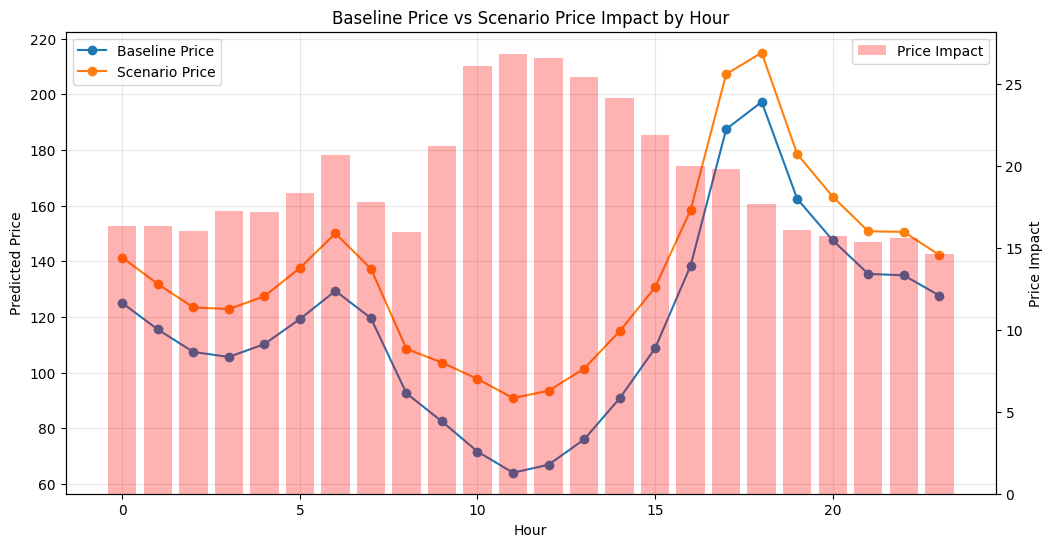

In [242]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(hour_price_impact['Hour'], hour_price_impact['Baseline_Price'],
         marker='o', label='Baseline Price')
ax1.plot(hour_price_impact['Hour'], hour_price_impact['Scenario_Price'],
         marker='o', label='Scenario Price')

ax1.set_xlabel('Hour')
ax1.set_ylabel('Predicted Price')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(hour_price_impact['Hour'], hour_price_impact['Price_Impact'],
        alpha=0.3, color='red', label='Price Impact')
ax2.set_ylabel('Price Impact')

plt.title('Baseline Price vs Scenario Price Impact by Hour')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [243]:
base_context = model_ready_df.copy()

base_context['Variable_Renewable_Dispatch'] = (
    base_context['solar_dispatch'] + base_context['wind_dispatch']
)

hour_market_context = (
    base_context
    .groupby('Hour')
    .agg(
        Avg_Demand=('NSW1_Demand', 'mean'),
        Avg_Solar=('solar_dispatch', 'mean'),
        Avg_Wind=('wind_dispatch', 'mean'),
        Avg_Net_Demand=('Net_Demand', 'mean')
    )
    .reset_index()
)

hour_explain = hour_price_impact.merge(hour_market_context, on='Hour')

hour_explain

,Hour,Baseline_Price,Scenario_Price,Price_Impact,Avg_Demand,Avg_Solar,Avg_Wind,Avg_Net_Demand
0,0,124.982811,141.313828,16.331017,7346.243587,0.072656,789.304595,6556.866336
1,1,115.472435,131.824158,16.351719,6929.452888,0.058247,778.803886,6150.590755
2,2,107.396858,123.387924,15.991058,6562.893285,0.055267,766.732041,5796.105977
3,3,105.603783,122.815239,17.211456,6409.085353,0.059255,755.583061,5653.443037
4,4,110.207428,127.406937,17.199511,6521.554379,0.067947,746.044761,5775.441671
5,5,119.208313,137.525894,18.317574,6945.033544,26.903409,731.746139,6186.383996
6,6,129.330566,149.987686,20.657116,7524.101038,304.031687,703.739156,6516.330195
7,7,119.539963,137.307922,17.767965,7817.202729,828.151634,652.156521,6336.894573
8,8,92.538193,108.512260,15.974073,7625.369977,1336.353496,593.800030,5695.216451
9,9,82.412430,103.594452,21.182020,7211.479020,1568.682727,553.970549,5088.825743


In [249]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# calculate extra procurement cost

cost_results = scenario_impact_results[
    scenario_impact_results['Cap_Model'] == 'p99'
].copy()

# 5-minute interval length in hours
interval_hours = 5 / 60

# Energy consumed by additional data-centre load in each interval
cost_results['Additional_DC_MWh'] = (
    cost_results['Additional_DC_MW'] * interval_hours
)

# Extra procurement cost caused by price impact
cost_results['Extra_Cost'] = (
    cost_results['Price_Impact'] * cost_results['Additional_DC_MWh']
)

cost_results.head()

,SETTLEMENTDATE,Hour,Season,DayType,PeakPeriod,LowRenewableFlag,DemandStressFlag,CoreSystemStressFlag,SevereSystemStressFlag,Cap_Model,Cap_Value,Scenario,FY,Additional_DC_MW,Baseline_Predicted_Price,Scenario_Predicted_Price,Price_Impact,Additional_DC_MWh,Extra_Cost
0,2021-07-02 01:00:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,96.525063,100.069603,3.544540,3.805,13.486976
1,2021-07-02 01:05:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,96.754066,97.946106,1.192039,3.805,4.535710
2,2021-07-02 01:10:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,89.491791,97.689873,8.198082,3.805,31.193702
3,2021-07-02 01:15:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,87.508080,89.491791,1.983711,3.805,7.548021
4,2021-07-02 01:20:00,1,Winter,Weekday,Off-peak,True,False,False,False,p99,541.89,Slower Growth,FY2026,45.66,81.434944,84.269844,2.834900,3.805,10.786794


In [250]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# annual procurement cost Impact by scenario

procurement_summary = (
    cost_results
    .groupby(['Scenario', 'FY', 'Additional_DC_MW'])
    .agg(
        Total_Extra_Cost=('Extra_Cost', 'sum'),
        Mean_Interval_Cost=('Extra_Cost', 'mean'),
        P95_Interval_Cost=('Extra_Cost', lambda x: x.quantile(0.95))
    )
    .reset_index()
)

procurement_summary

,Scenario,FY,Additional_DC_MW,Total_Extra_Cost,Mean_Interval_Cost,P95_Interval_Cost
0,Accelerated Transition,FY2026,114.16,1.041926e+07,33.070729,108.475814
1,Accelerated Transition,FY2027,273.97,5.976564e+07,189.696043,524.584964
2,Accelerated Transition,FY2028,502.28,2.000609e+08,634.993020,1647.481611
3,Accelerated Transition,FY2029,799.09,5.048148e+08,1602.281346,4011.683167
4,Accelerated Transition,FY2030,1221.46,1.187460e+09,3768.996840,9085.428278
5,Slower Growth,FY2026,45.66,1.669512e+06,5.299029,22.459327
6,Slower Growth,FY2027,91.32,6.677701e+06,21.195014,73.362396
7,Slower Growth,FY2028,136.99,1.499956e+07,47.608575,149.781779
8,Slower Growth,FY2029,194.06,3.007590e+07,95.460853,280.567559
9,Slower Growth,FY2030,262.56,5.489698e+07,174.242934,485.414866


In [251]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# convert to millions

procurement_summary['Total_Extra_Cost_Million'] = (
    procurement_summary['Total_Extra_Cost'] / 1_000_000
)

procurement_summary

,Scenario,FY,Additional_DC_MW,Total_Extra_Cost,Mean_Interval_Cost,P95_Interval_Cost,Total_Extra_Cost_Million
0,Accelerated Transition,FY2026,114.16,1.041926e+07,33.070729,108.475814,10.419264
1,Accelerated Transition,FY2027,273.97,5.976564e+07,189.696043,524.584964,59.765635
2,Accelerated Transition,FY2028,502.28,2.000609e+08,634.993020,1647.481611,200.060901
3,Accelerated Transition,FY2029,799.09,5.048148e+08,1602.281346,4011.683167,504.814761
4,Accelerated Transition,FY2030,1221.46,1.187460e+09,3768.996840,9085.428278,1187.460144
5,Slower Growth,FY2026,45.66,1.669512e+06,5.299029,22.459327,1.669512
6,Slower Growth,FY2027,91.32,6.677701e+06,21.195014,73.362396,6.677701
7,Slower Growth,FY2028,136.99,1.499956e+07,47.608575,149.781779,14.999558
8,Slower Growth,FY2029,194.06,3.007590e+07,95.460853,280.567559,30.075896
9,Slower Growth,FY2030,262.56,5.489698e+07,174.242934,485.414866,54.896979


In [253]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Hedging relevant Tail exposure, focusing only on high impact intervals

hedging_summary = (
    cost_results
    .groupby(['Scenario', 'FY'])
    .agg(
        Mean_Impact=('Price_Impact', 'mean'),
        P75_Impact=('Price_Impact', lambda x: x.quantile(0.75)),
        P95_Impact=('Price_Impact', lambda x: x.quantile(0.95)),
        P99_Impact=('Price_Impact', lambda x: x.quantile(0.99)),
        Mean_Interval_Cost=('Extra_Cost', 'mean'),
        P95_Interval_Cost=('Extra_Cost', lambda x: x.quantile(0.95)),
        P99_Interval_Cost=('Extra_Cost', lambda x: x.quantile(0.99))
    )
    .reset_index()
)

hedging_summary


,Scenario,FY,Mean_Impact,P75_Impact,P95_Impact,P99_Impact,Mean_Interval_Cost,P95_Interval_Cost,P99_Interval_Cost
0,Accelerated Transition,FY2026,3.476251,5.116011,11.402503,18.981997,33.070729,108.475814,180.582069
1,Accelerated Transition,FY2027,8.308765,11.811941,22.977039,35.843765,189.696043,524.584964,818.343053
2,Accelerated Transition,FY2028,15.170655,21.374367,39.360077,58.176399,634.993020,1647.481611,2435.070090
3,Accelerated Transition,FY2029,24.061590,34.095749,60.243774,86.126305,1602.281346,4011.683167,5735.222468
4,Accelerated Transition,FY2030,37.027790,53.042007,89.258049,123.199043,3768.996840,9085.428278,12540.225322
5,Slower Growth,FY2026,1.392649,2.143087,5.902583,10.698719,5.299029,22.459327,40.708627
6,Slower Growth,FY2027,2.785153,4.151926,9.640263,16.434477,21.195014,73.362396,125.066371
7,Slower Growth,FY2028,4.170399,6.060511,13.120529,21.458862,47.608575,149.781779,244.970804
8,Slower Growth,FY2029,5.902969,8.468739,17.349329,27.543695,95.460853,280.567559,445.427465
9,Slower Growth,FY2030,7.963571,11.354982,22.185324,34.684059,174.242934,485.414866,758.887191


In [254]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# stress-period hedging exposure (core system stress flag)

stress_cost_summary = (
    cost_results
    .groupby(['Scenario', 'FY', 'CoreSystemStressFlag'])
    .agg(
        Observations=('Extra_Cost', 'count'),
        Total_Extra_Cost=('Extra_Cost', 'sum'),
        Mean_Interval_Cost=('Extra_Cost', 'mean'),
        P95_Interval_Cost=('Extra_Cost', lambda x: x.quantile(0.95))
    )
    .reset_index()
)

stress_cost_summary['Total_Extra_Cost_Million'] = (
    stress_cost_summary['Total_Extra_Cost'] / 1_000_000
)

stress_cost_summary

,Scenario,FY,CoreSystemStressFlag,Observations,Total_Extra_Cost,Mean_Interval_Cost,P95_Interval_Cost,Total_Extra_Cost_Million
0,Accelerated Transition,FY2026,False,307707,1.012456e+07,32.903264,106.794352,10.124565
1,Accelerated Transition,FY2026,True,7353,2.946992e+05,40.078768,198.290406,0.294699
2,Accelerated Transition,FY2027,False,307302,5.803410e+07,188.850388,517.515466,58.034102
3,Accelerated Transition,FY2027,True,7758,1.731533e+06,223.193261,755.893633,1.731533
4,Accelerated Transition,FY2028,False,306898,1.941316e+08,632.560758,1629.273544,194.131632
5,Accelerated Transition,FY2028,True,8162,5.929269e+06,726.448094,2104.663561,5.929269
6,Accelerated Transition,FY2029,False,306645,4.897555e+08,1597.141683,3988.653236,489.755512
7,Accelerated Transition,FY2029,True,8415,1.505925e+07,1789.572134,4718.803291,15.059250
8,Accelerated Transition,FY2030,False,306578,1.153176e+09,3761.444519,9069.535267,1153.176138
9,Accelerated Transition,FY2030,True,8482,3.428401e+07,4041.972028,9563.318027,34.284007


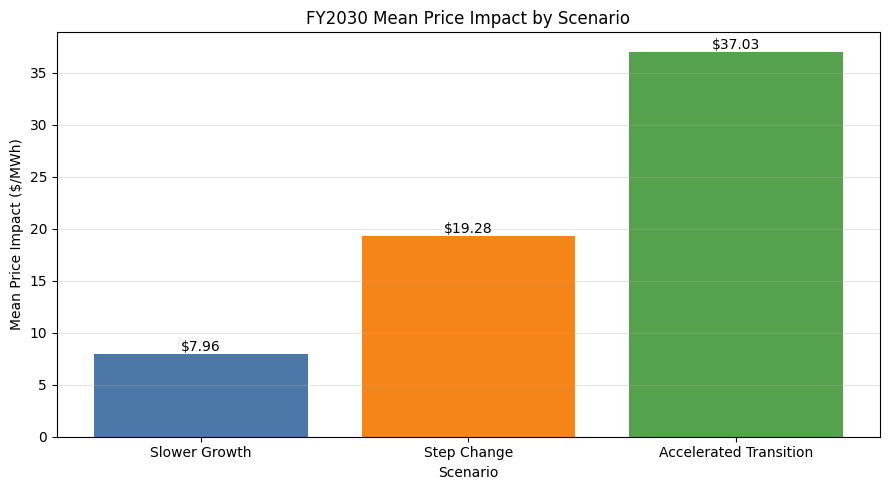

In [256]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Read the CSV file
overall_summary_lagfree = pd.read_csv('overall_summary_lagfree.csv')

# Filter to p99 main model and FY2030
plot_df = overall_summary_lagfree[
    (overall_summary_lagfree['Cap_Model'] == 'p99') &
    (overall_summary_lagfree['FY'] == 'FY2030')
].copy()

# Keep scenarios in logical order
scenario_order = ['Slower Growth', 'Step Change', 'Accelerated Transition']
plot_df['Scenario'] = pd.Categorical(
    plot_df['Scenario'],
    categories=scenario_order,
    ordered=True
)

plot_df = plot_df.sort_values('Scenario')

# Plot vertical bar chart
plt.figure(figsize=(9, 5))

plt.bar(
    plot_df['Scenario'],
    plot_df['Mean_Impact'],
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title('FY2030 Mean Price Impact by Scenario')
plt.xlabel('Scenario')
plt.ylabel('Mean Price Impact ($/MWh)')
plt.grid(axis='y', alpha=0.3)

# Add labels above bars
for i, value in enumerate(plot_df['Mean_Impact']):
    plt.text(i, value, f'${value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

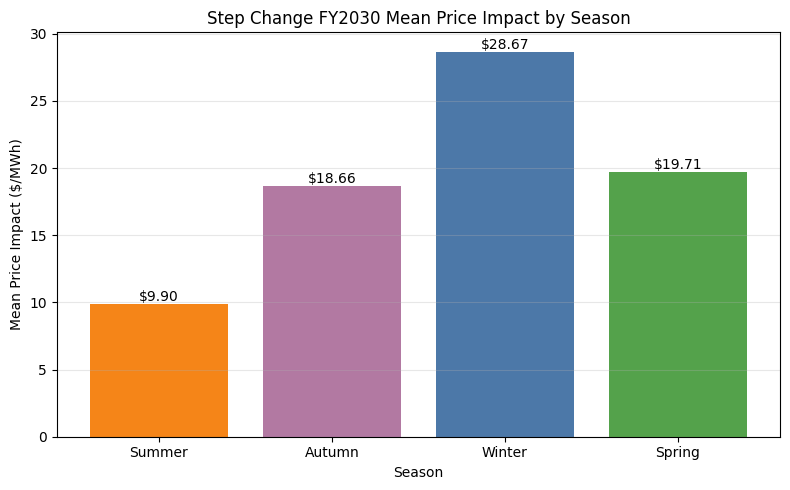

In [257]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Read the CSV file
season_summary_lagfree = pd.read_csv('season_summary_lagfree.csv')

# Use p99 main model, Step Change, FY2030
plot_df = season_summary_lagfree[
    (season_summary_lagfree['Cap_Model'] == 'p99') &
    (season_summary_lagfree['Scenario'] == 'Step Change') &
    (season_summary_lagfree['FY'] == 'FY2030')
].copy()

# Order seasons in Australian calendar order
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
plot_df['Season'] = pd.Categorical(
    plot_df['Season'],
    categories=season_order,
    ordered=True
)

plot_df = plot_df.sort_values('Season')

# Plot vertical bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    plot_df['Season'],
    plot_df['Mean_Impact'],
    color=['#F58518', '#B279A2', '#4C78A8', '#54A24B']
)

plt.title('Step Change FY2030 Mean Price Impact by Season')
plt.xlabel('Season')
plt.ylabel('Mean Price Impact ($/MWh)')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, value in enumerate(plot_df['Mean_Impact']):
    plt.text(
        i,
        value,
        f'${value:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

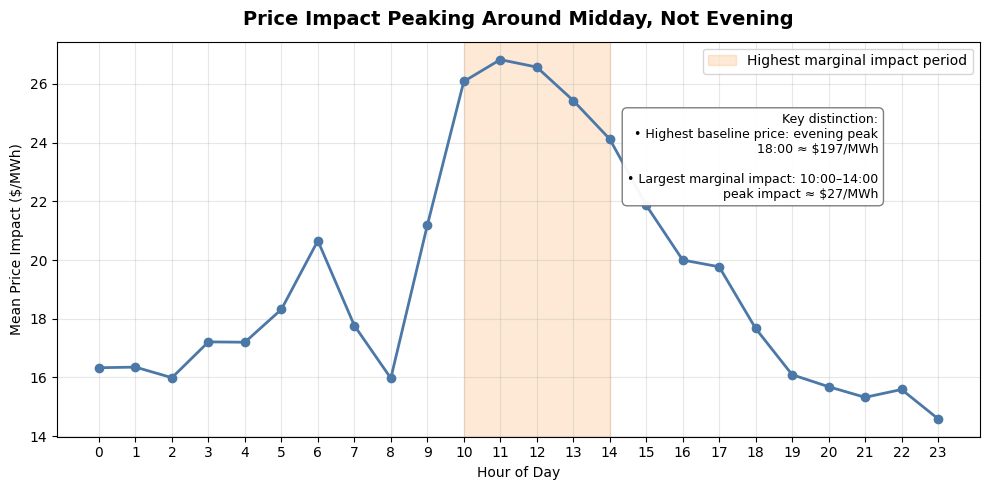

In [274]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Read the CSV file
hour_summary_lagfree = pd.read_csv('hour_summary_lagfree.csv')

# Use p99 main model, Step Change, FY2030
plot_df = hour_summary_lagfree[
    (hour_summary_lagfree['Cap_Model'] == 'p99') &
    (hour_summary_lagfree['Scenario'] == 'Step Change') &
    (hour_summary_lagfree['FY'] == 'FY2030')
].copy()

plot_df = plot_df.sort_values('Hour')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot hour-of-day line chart
ax.plot(
    plot_df['Hour'],
    plot_df['Mean_Impact'],
    marker='o',
    linewidth=2,
    color='#4C78A8'
)

# Highlight 10:00-14:00 period
ax.axvspan(
    10,
    14,
    color='#F58518',
    alpha=0.18,
    label='Highest marginal impact period'
)

# Updated title
ax.set_title(
    'Price Impact Peaking Around Midday, Not Evening',
    fontsize=14,
    fontweight='bold',
    pad=12
)

# Small explanatory textbox
textbox = (
    'Key distinction:\n'
    'â€¢ Highest baseline price: evening peak\n'
    '  18:00 â‰ˆ $197/MWh\n\n'
    'â€¢ Largest marginal impact: 10:00â€“14:00\n'
    '  peak impact â‰ˆ $27/MWh'
)

# Textbox moved to the right, aligned safely inside the plot
ax.text(
    0.89,
    0.82,
    textbox,
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    ha='right',
    bbox=dict(
        boxstyle='round,pad=0.4',
        fc='white',
        ec='#777777',
        alpha=0.95
    )
)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Price Impact ($/MWh)')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

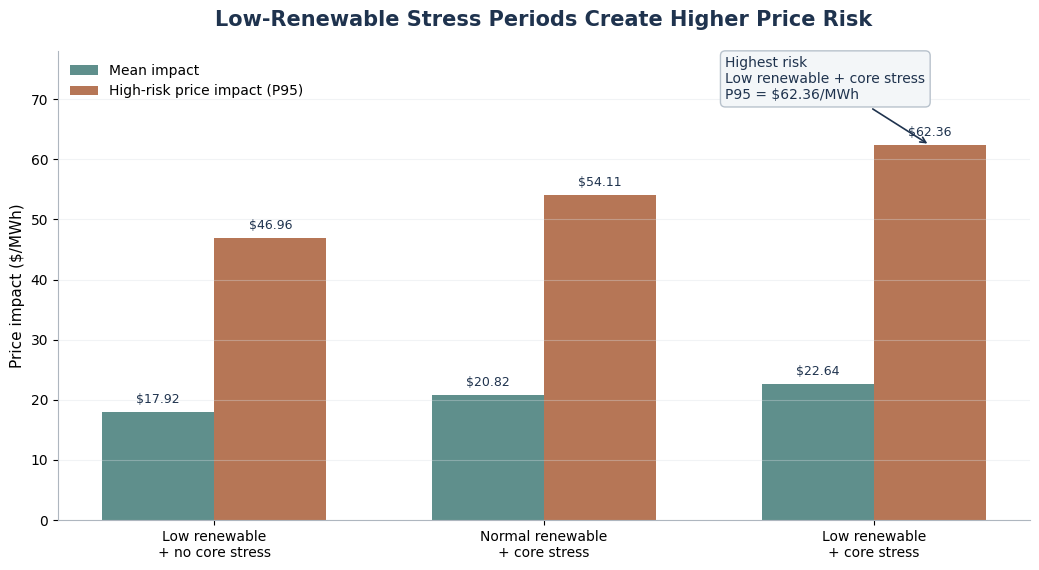

In [260]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.

# Data: Step Change FY2030, p99 model
plot_df = pd.DataFrame({
    'Condition': [
        'Low renewable\n+ no core stress',
        'Normal renewable\n+ core stress',
        'Low renewable\n+ core stress'
    ],
    'Mean impact': [17.92, 20.82, 22.64],
    'High-risk price impact (P95)': [46.96, 54.11, 62.36]
})

x = np.arange(len(plot_df))
width = 0.34

# Professional colour palette
mean_color = '#5F8F8C'      # muted teal
p95_color = '#B67656'       # muted copper
text_color = '#1F334E'      # navy
grid_color = '#D9DEE3'

plt.figure(figsize=(10.5, 5.8))
ax = plt.gca()

# Bars
bars1 = ax.bar(
    x - width/2,
    plot_df['Mean impact'],
    width,
    label='Mean impact',
    color=mean_color
)

bars2 = ax.bar(
    x + width/2,
    plot_df['High-risk price impact (P95)'],
    width,
    label='High-risk price impact (P95)',
    color=p95_color
)

# Title and labels
ax.set_title(
    'Low-Renewable Stress Periods Create Higher Price Risk',
    fontsize=15,
    fontweight='bold',
    color=text_color,
    pad=18
)

ax.set_ylabel('Price impact ($/MWh)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Condition'], fontsize=10)

# Grid and styling
ax.grid(axis='y', alpha=0.35, color=grid_color)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#AEB6BF')
ax.spines['bottom'].set_color('#AEB6BF')

ax.legend(
    frameon=False,
    loc='upper left',
    fontsize=10
)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1.0,
            f'${height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
            color=text_color
        )

# Callout box
ax.annotate(
    'Highest risk\nLow renewable + core stress\nP95 = $62.36/MWh',
    xy=(x[2] + width/2, 62.36),
    xytext=(1.55, 70),
    arrowprops=dict(
        arrowstyle='->',
        color=text_color,
        lw=1.2
    ),
    bbox=dict(
        boxstyle='round,pad=0.35',
        fc='#F3F6F8',
        ec='#B8C2CC'
    ),
    fontsize=10,
    color=text_color
)

ax.set_ylim(0, 78)

plt.tight_layout()
plt.show()

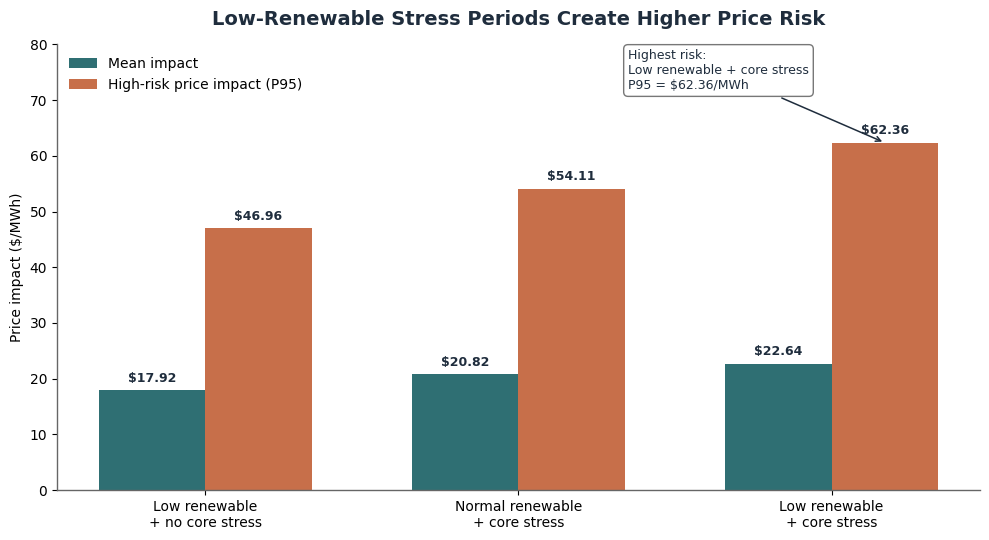

In [264]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.


# Data: Step Change FY2030, p99 model
plot_df = pd.DataFrame({
    'Condition': [
        'Low renewable\n+ no core stress',
        'Normal renewable\n+ core stress',
        'Low renewable\n+ core stress'
    ],
    'Mean impact': [17.92, 20.82, 22.64],
    'High-risk price impact (P95)': [46.96, 54.11, 62.36]
})

x = np.arange(len(plot_df))
width = 0.34

# New professional colour combination
mean_color = '#2F6F73'      # deep teal
p95_color = '#C76F4A'       # muted terracotta
text_color = '#1F2D3D'

plt.figure(figsize=(10, 5.5))
ax = plt.gca()

# Bars
bars1 = ax.bar(
    x - width/2,
    plot_df['Mean impact'],
    width,
    label='Mean impact',
    color=mean_color
)

bars2 = ax.bar(
    x + width/2,
    plot_df['High-risk price impact (P95)'],
    width,
    label='High-risk price impact (P95)',
    color=p95_color
)

# Title and labels
ax.set_title(
    'Low-Renewable Stress Periods Create Higher Price Risk',
    fontsize=14,
    fontweight='bold',
    color=text_color,
    pad=14
)

ax.set_ylabel('Price impact ($/MWh)')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Condition'])

# Remove grid lines
ax.grid(False)

# Clean border style
for spine in ax.spines.values():
    spine.set_color('#666666')
    spine.set_linewidth(1)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f'${height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color=text_color
        )

# Callout
ax.annotate(
    'Highest risk:\nLow renewable + core stress\nP95 = $62.36/MWh',
    xy=(x[2] + width/2, 62.36),
    xytext=(1.35, 72),
    arrowprops=dict(
        arrowstyle='->',
        color=text_color,
        lw=1.1
    ),
    bbox=dict(
        boxstyle='round,pad=0.35',
        fc='white',
        ec='#777777'
    ),
    fontsize=9,
    color=text_color
)

ax.legend(frameon=False, loc='upper left')
ax.set_ylim(0, 80)
# Remove the top horizontal border line
ax.spines['top'].set_visible(False)

# Optional: also remove right border for a cleaner look
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

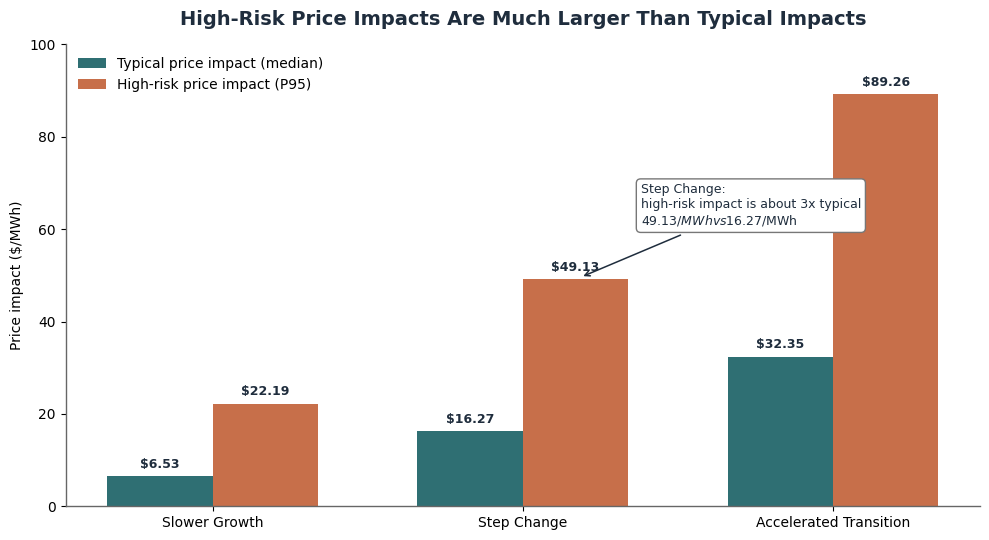

In [268]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# Data: FY2030, p99 model
plot_df = pd.DataFrame({
    'Scenario': [
        'Slower Growth',
        'Step Change',
        'Accelerated Transition'
    ],
    'Typical Price Impact (Median)': [6.53, 16.27, 32.35],
    'High-risk Price Impact (P95)': [22.19, 49.13, 89.26]
})

x = np.arange(len(plot_df))
width = 0.34

# Same theme colours
median_color = '#2F6F73'    # deep teal
p95_color = '#C76F4A'       # muted terracotta
text_color = '#1F2D3D'

plt.figure(figsize=(10, 5.5))
ax = plt.gca()

# Bars
bars1 = ax.bar(
    x - width/2,
    plot_df['Typical Price Impact (Median)'],
    width,
    label='Typical price impact (median)',
    color=median_color
)

bars2 = ax.bar(
    x + width/2,
    plot_df['High-risk Price Impact (P95)'],
    width,
    label='High-risk price impact (P95)',
    color=p95_color
)

# Title and labels
ax.set_title(
    'High-Risk Price Impacts Are Much Larger Than Typical Impacts',
    fontsize=14,
    fontweight='bold',
    color=text_color,
    pad=14
)

ax.set_ylabel('Price impact ($/MWh)')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Scenario'])

# Remove grid lines
ax.grid(False)

# Clean border style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_color('#666666')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1.2,
            f'${height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color=text_color
        )

# Callout
# Callout - cleaner placement
# Callout - shorter arrow and cleaner text spacing
ax.annotate(
    'Step Change:\nhigh-risk impact is about 3x typical\n$49.13/MWh vs $16.27/MWh',
    xy=(x[1] + width/2, 49.13),
    xytext=(1.38, 61),
    arrowprops=dict(
        arrowstyle='->',
        color=text_color,
        lw=1.1,
        shrinkA=4,
        shrinkB=6
    ),
    bbox=dict(
        boxstyle='round,pad=0.35',
        fc='white',
        ec='#777777'
    ),
    fontsize=9,
    color=text_color
)


ax.legend(frameon=False, loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Visualizations to analyze Price Impact based on scenarios

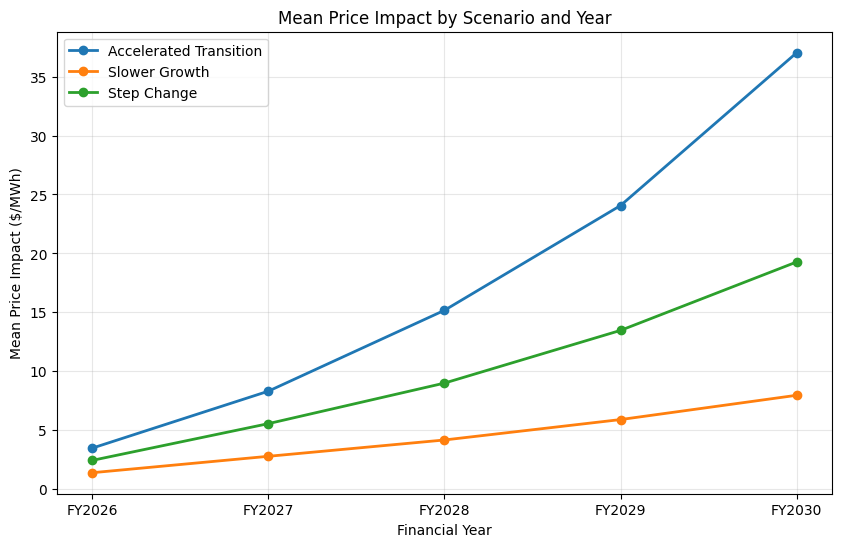

In [141]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 1. Mean impact by scenario and year
# Use p99 as the main model result
# ------------------------------------------------------------

main_cap = 'p99'

plot_overall = overall_summary[
    overall_summary['Cap_Model'] == main_cap
].copy()

plt.figure(figsize=(10, 6))

for scenario in plot_overall['Scenario'].unique():
    data = plot_overall[plot_overall['Scenario'] == scenario]
    
    plt.plot(
        data['FY'],
        data['Mean_Impact'],
        marker='o',
        linewidth=2,
        label=scenario
    )

plt.title('Mean Price Impact by Scenario and Year')
plt.xlabel('Financial Year')
plt.ylabel('Mean Price Impact ($/MWh)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

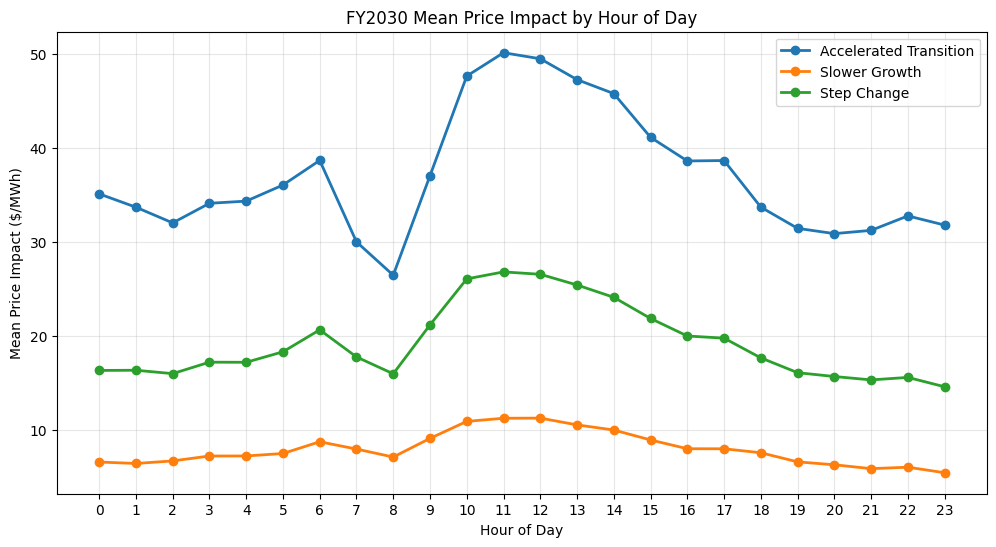

In [142]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 2. FY2030 impact by hour of day
# ------------------------------------------------------------

plot_hour = hour_summary[
    (hour_summary['Cap_Model'] == main_cap) &
    (hour_summary['FY'] == 'FY2030')
].copy()

plt.figure(figsize=(12, 6))

for scenario in plot_hour['Scenario'].unique():
    data = plot_hour[plot_hour['Scenario'] == scenario]
    
    plt.plot(
        data['Hour'],
        data['Mean_Impact'],
        marker='o',
        linewidth=2,
        label=scenario
    )

plt.title('FY2030 Mean Price Impact by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Price Impact ($/MWh)')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

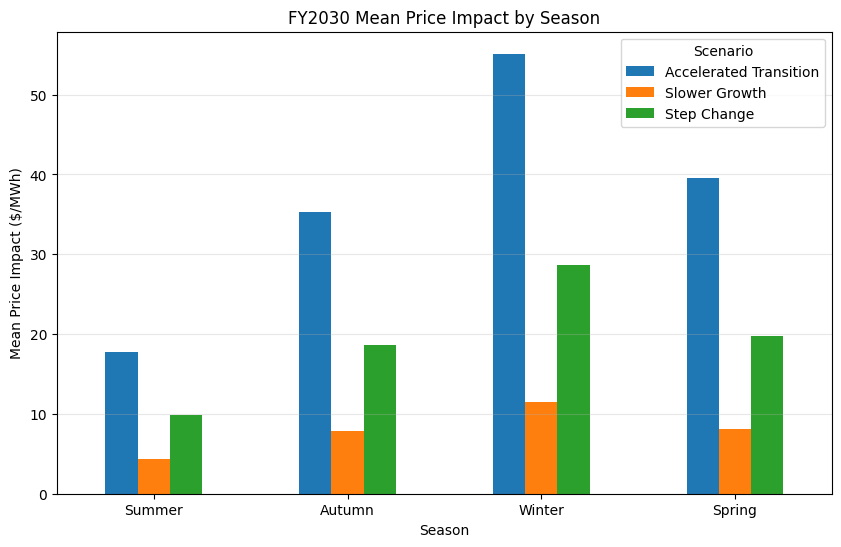

In [143]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 3. FY2030 impact by season
# ------------------------------------------------------------

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']

plot_season = season_summary[
    (season_summary['Cap_Model'] == main_cap) &
    (season_summary['FY'] == 'FY2030')
].copy()

plot_season['Season'] = pd.Categorical(
    plot_season['Season'],
    categories=season_order,
    ordered=True
)

plot_season = plot_season.sort_values(['Scenario', 'Season'])

season_pivot = plot_season.pivot(
    index='Season',
    columns='Scenario',
    values='Mean_Impact'
)

season_pivot.plot(kind='bar', figsize=(10, 6))

plt.title('FY2030 Mean Price Impact by Season')
plt.xlabel('Season')
plt.ylabel('Mean Price Impact ($/MWh)')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Scenario')
plt.show()

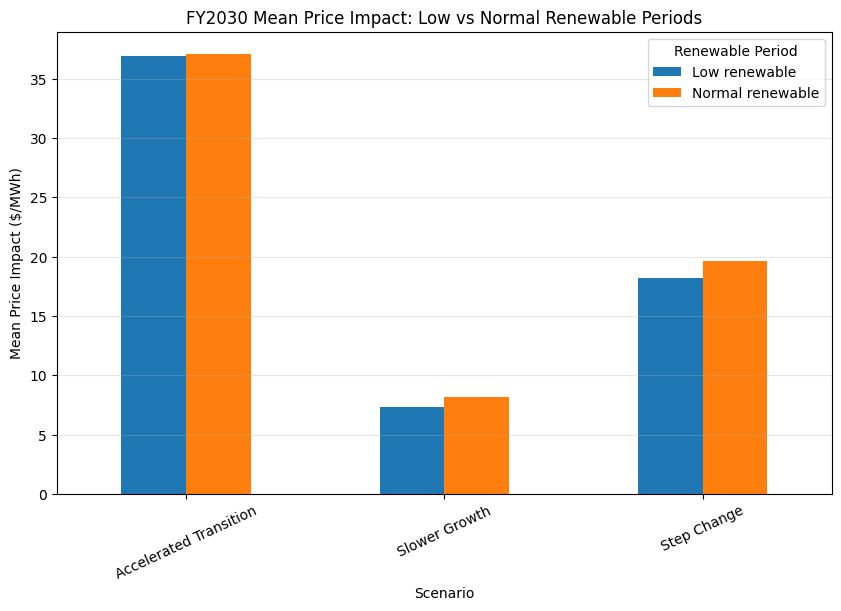

In [144]:
# [REMOVABLE] Auxiliary or redundant cell; deleting it does not affect the core cleaning, modelling, training, evaluation, or scenario results.
# ------------------------------------------------------------
# 4. Low-renewable vs normal-renewable impact
# ------------------------------------------------------------

plot_low_renew = low_renewable_summary[
    (low_renewable_summary['Cap_Model'] == main_cap) &
    (low_renewable_summary['FY'] == 'FY2030')
].copy()

plot_low_renew['Renewable_Period'] = np.where(
    plot_low_renew['LowRenewableFlag'] == True,
    'Low renewable',
    'Normal renewable'
)

low_renew_pivot = plot_low_renew.pivot(
    index='Scenario',
    columns='Renewable_Period',
    values='Mean_Impact'
)

low_renew_pivot.plot(kind='bar', figsize=(10, 6))

plt.title('FY2030 Mean Price Impact: Low vs Normal Renewable Periods')
plt.xlabel('Scenario')
plt.ylabel('Mean Price Impact ($/MWh)')
plt.xticks(rotation=25)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Renewable Period')
plt.show()

### Final Model Selection: Capped-Price Prediction Model

After adding engineered features and capping extreme RRP values at the training 99th percentile ($541.89/MWh), model performance improved substantially. The engineered features included lagged price, lagged demand, rolling 1-hour price, total renewable dispatch, and net demand. These features helped capture short-term price persistence and market-balance conditions that were not fully represented in the earlier models.

The Extra Trees model improved strongly compared with the earlier capped model, achieving an MAE of **$17.09/MWh**, RMSE of **$39.14/MWh**, and RÂ² of **0.787**. This shows that the engineered features significantly improved the modelâ€™s ability to explain normal-to-high price behaviour.

XGBoost performed slightly better overall, with an MAE of **$15.95/MWh**, RMSE of **$38.38/MWh**, and RÂ² of **0.795**. It also performed particularly well during core and severe system-stress periods, which are most relevant for Task 2. Severe stress performance improved to an RÂ² of **0.931** and MAE of **$18.58/MWh**, suggesting that the model captures high-demand, low-solar, evening/winter price-pressure conditions effectively.

Therefore, **XGBoost is selected as the final model** for capped-price scenario analysis, while Extra Trees is retained as a comparison model and Multiple Linear Regression is retained as a transparent baseline.

However, because the target variable is capped, this model should be interpreted as a model of **normal to high-but-controlled wholesale prices**, not a model of the true magnitude of extreme price spikes above the cap. Extreme price events remain important for risk discussion, but their full magnitude is not predicted by the capped model.